# Inter-laminar oscillatory signaling delays

**Supplement to `grand_oscillatory_csds.ipynb`.** A reviewer asked us to quantify signaling delays
between laminar layers by the difference in trough (phase = π) times across the L4, L2/3 and L5/6
functional groupings, within band and condition — i.e. to show how each band's oscillation phase
*propagates* between layers (cf. van Kerkoerle et al. 2014).

For each `(condition, band, area)` we take a representative band-phase per layer with the same
`band_phases` used in the CSD notebook (it reduces to the middle channel of the selected layer), then
measure the inter-laminar delay two complementary ways:

1. **Trough-time differences** (the reviewer's literal request): within each trial, match every
   trough in a reference layer to the nearest trough in a target layer (constrained to < half a cycle)
   and record Δt = t_target − t_reference in ms.
2. **Circular phase-difference delay** (robust cross-check over *all* timepoints):
   Δt = circmean(φ_target − φ_reference) / (2π·f_center).

Sign convention: **positive Δt ⇒ the trough arrives later in the target layer ⇒ the wave propagates
reference → target.** We reference to the granular input layer L4, giving L4→L2/3, L4→L5/6 and the
L2/3→L5/6 pair.

We also corroborate with the **CSD sink latency**: from the L4-trough-triggered laminar CSD (the van
Kerkoerle construction already in the CSD notebook) we read off, per layer, the time of the current
**sink** (most negative CSD) and compare its cross-layer timing to the phase delays.

Statistics use one delay per trial (avoiding pseudoreplication across the many cycles per trial):
a Wilcoxon signed-rank test that the delay ≠ 0, a Rayleigh test that a consistent phase relationship
exists, and a permutation test for condition contrasts. Everything is **grand-pooled** across mice
(via `grandcat`), matching the CSD figures.

> Data note: `grandcat` pools mice into one trial axis and double-counts the mice with two probes in
> one area (`sub-637908` in RL, `sub-621890`/`sub-632485` in LM). That inflates trial counts in those
> areas; interpret the per-trial tests there with that in mind.

In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import quantities as pq
from scipy import stats

import epych
from epych import plotting
from epych.statistics import alignment, spectrum

[striatum:371704] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/3718250496/shared_mem_cuda_pool.striatum could be created.
[striatum:371704] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

## Constants (shared with `grand_oscillatory_csds.ipynb`)

In [6]:
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
OFFSET = pq.Quantity(0.050) * pq.second
EVENTS = {"Oddball": (ODDBALL_ONSET.magnitude, 'lightgreen'),
          "Offset": (ODDBALL_OFFSET.magnitude, 'red')}
FORCE_RECOMPUTE = False

In [7]:
CONDITIONS = ["lonaive", "go_gloexp", "go_seqctl", "lo_gloexp", "lo_rndctl", "igo_seqctl"]
CONTRASTS = [("go_contrast", "go_gloexp", "go_seqctl"),
             ("ssa", "lo_gloexp", "igo_seqctl"),
             ("dd", "lo_rndctl", "lonaive")]
CONDITION_TITLES = {
    "lonaive": "Habituation", "go_gloexp": "xxxX [B1]", "go_seqctl": "xxxx [B3]",
    "lo_gloexp": "xxxY [B1]", "lo_rndctl": "XXXY [B2]", "igo_seqctl": "yyyy [B3]"}
CONTRAST_TITLES = {"go_contrast": "Global Oddball",
                   "ssa": "Stimulus Specific Adaptation", "dd": "Deviance Detection"}

In [8]:
AREA_TITLES = {"VISal": "AL", "VISam": "AM", "VISl": "LM",
               "VISp": "V1", "VISpm": "PM", "VISrl": "RL"}
def stattitle(name, stat=None):
    return AREA_TITLES.get(name, name)
ANATOMICAL_AREAS = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [9]:
# Bands (Hz) -> (filename stem, LaTeX). Same three bands as the CSD notebook.
BANDS = {(4, 8): ("theta", "$\\theta$"),
         (12, 24): ("alphabeta", "$\\alpha/\\beta$"),
         (30, 50): ("gamma", "$\\gamma$")}
def band_center(band):
    return (band[0] + band[1]) / 2.0

# Laminar functional groupings (the LAMINAE selectors from oscillatory_contrasts.ipynb).
LAYERS = collections.OrderedDict([
    ("L4",   lambda loc: "4" in loc),
    ("L2/3", lambda loc: "2/3" in loc),
    ("L5/6", lambda loc: "5" in loc or "6" in loc),
])
LAYER_STEM = {"L4": "L4", "L2/3": "L23", "L5/6": "L56"}
# (reference, target); positive delay => target trough later => propagation reference -> target.
LAYER_PAIRS = [("L4", "L2/3"), ("L4", "L5/6"), ("L2/3", "L5/6")]
def pair_label(pair):
    return "%s\u2192%s" % pair

In [10]:
def oddball(signal):
    return signal[(ODDBALL_ONSET - OFFSET).magnitude:(ODDBALL_OFFSET + OFFSET).magnitude].fmap(
        lambda data: data.rescale("uV"))

## Per-layer band phases

`band_phases` reduces to the middle channel of the selected layer, so each call yields one reference
phase per `(condition, band, area, layer)`. **L4 reuses the cache already written by
`grand_oscillatory_csds.ipynb`** (`oscillatory_phases/<cond>_<band>`); L2/3 and L5/6 are computed here
(layer-suffixed keys) and cached, so reruns are cheap.

In [11]:
PHASE_DIR = "/mnt/data/000253/oscillatory_phases"

def phase_cache_key(cond, band, layer):
    if layer == "L4":                       # reuse the CSD notebook's L4 cache verbatim
        return "%s/%s_%s" % (PHASE_DIR, cond, band)
    return "%s/%s_%s_%s" % (PHASE_DIR, cond, band, LAYER_STEM[layer])

def layer_phases(oddballs, cond, band, layer):
    key = phase_cache_key(cond, band, layer)
    if os.path.exists(key) and not FORCE_RECOMPUTE:
        return epych.recording.Sampling.unpickle(key)
    selector = LAYERS[layer]
    os.makedirs(PHASE_DIR, exist_ok=True)
    phases = oddballs.smap(lambda sig: sig.select_channels(
        [selector(loc) for loc in sig.channels.location.values]).band_phases(
            band[0] * pq.Hz, band[1] * pq.Hz))
    phases.pickle(key)
    logging.info("Computed %s phases for %s %s", layer, cond, band)
    return phases

## Delay estimators and statistics

In [12]:
def trough_samples(phase_1d):
    """Indices of oscillation troughs: the 2π downward wrap where Hilbert phase jumps +π -> -π."""
    return np.where(np.diff(phase_1d) < -np.pi)[0]

def trough_time_delays(ref_sig, tgt_sig, period_s):
    """Per-trial mean nearest-trough delay (ms) and the pooled per-trough deltas (ms)."""
    ref = ref_sig.data.magnitude[0]                     # (T, trials)
    tgt = tgt_sig.data.magnitude[0]
    dt = ref_sig.dt.rescale("s").magnitude
    half = period_s / 2.0
    per_trial, pooled = [], []
    for tr in range(ref.shape[1]):
        rt = trough_samples(ref[:, tr]) * dt
        tt = trough_samples(tgt[:, tr]) * dt
        if len(rt) == 0 or len(tt) == 0:
            per_trial.append(np.nan); continue
        deltas = []
        for t in rt:
            d = tt[np.argmin(np.abs(tt - t))] - t
            if abs(d) < half:
                deltas.append(d)
        pooled.extend(deltas)
        per_trial.append(np.mean(deltas) * 1000.0 if deltas else np.nan)
    return np.array(per_trial), np.array(pooled) * 1000.0

def per_trial_phase_diff(ref_sig, tgt_sig):
    """Circular-mean phase *lag* of target behind reference (rad) per trial.

    Uses ref - tgt so the sign matches the trough-time delay: if the target lags (its trough arrives
    later), its instantaneous phase is behind the reference, and ref - tgt is positive. Dividing by
    2*pi*f_center then yields a positive delay for propagation reference -> target."""
    ref = ref_sig.data.magnitude[0]
    tgt = tgt_sig.data.magnitude[0]
    d = np.angle(np.exp(1j * (ref - tgt)))              # wrapped (T, trials); +ve => target lags
    return stats.circmean(d, high=np.pi, low=-np.pi, axis=0)

def rayleigh(angles):
    a = angles[~np.isnan(angles)]
    n = len(a)
    if n < 2:
        return np.nan, np.nan
    R = np.abs(np.mean(np.exp(1j * a)))
    z = n * R * R
    p = np.exp(-z) * (1 + (2 * z - z ** 2) / (4 * n))   # Zar's approximation
    return R, min(p, 1.0)

In [13]:
def permutation_diff(a, b, n_perm=5000, seed=0):
    """Two-sided permutation test on the difference of medians (a - b)."""
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan
    obs = np.median(a) - np.median(b)
    pooled = np.concatenate([a, b]); na = len(a)
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        if abs(np.median(perm[:na]) - np.median(perm[na:])) >= abs(obs):
            count += 1
    return obs, (count + 1) / (n_perm + 1)

def stars(p):
    if p is None or np.isnan(p):
        return ""
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "n.s."


## Compute the inter-laminar phase delays

Loads `grandcat` per condition, takes the oddball window, and for each band fills
`delays[cond][band][area][pair]` with per-trial trough-time and phase-difference delays plus the
significance tests. The heavy phase objects are freed after each `(cond, band)`.

In [14]:
def blank_area_dict():
    return {area: {pair: None for pair in LAYER_PAIRS} for area in ANATOMICAL_AREAS}
delays = {cond: {band: blank_area_dict() for band in BANDS} for cond in CONDITIONS}

for cond in CONDITIONS:
    logging.info("Inter-laminar delays: loading LFPs for %s", cond)
    sampling = epych.recording.Sampling.unpickle("/mnt/data/000253/grandcat_%s" % cond)
    oddballs = sampling.smap(oddball)
    del sampling
    oddballs._signals = {k: v for k, v in oddballs.signals.items() if k in ANATOMICAL_AREAS}

    for band in BANDS:
        fc = band_center(band)
        period_s = 1.5 / fc                             # 1.5-cycle window, as in the CSD notebook
        phases = {layer: layer_phases(oddballs, cond, band, layer) for layer in LAYERS}
        for area in ANATOMICAL_AREAS:
            for (ref, tgt) in LAYER_PAIRS:
                rsig, tsig = phases[ref].signals[area], phases[tgt].signals[area]
                per_trial_ms, pooled_ms = trough_time_delays(rsig, tsig, period_s)
                phase_rad = per_trial_phase_diff(rsig, tsig)
                delay_ms = phase_rad / (2 * np.pi * fc) * 1000.0
                valid = delay_ms[~np.isnan(delay_ms)]
                _, wilcox_p = (stats.wilcoxon(valid) if len(valid) > 1 and np.any(valid != 0)
                               else (np.nan, np.nan))
                R, rayl_p = rayleigh(phase_rad)
                delays[cond][band][area][(ref, tgt)] = {
                    "trough_per_trial_ms": per_trial_ms,
                    "trough_pooled_ms": pooled_ms,
                    "phase_delay_ms": delay_ms,
                    "phase_rad": phase_rad,
                    "mean_phase_ms": float(stats.circmean(
                        phase_rad[~np.isnan(phase_rad)], high=np.pi, low=-np.pi)
                        / (2 * np.pi * fc) * 1000.0) if np.any(~np.isnan(phase_rad)) else np.nan,
                    "median_trough_ms": float(np.nanmedian(per_trial_ms)),
                    "wilcoxon_p": wilcox_p, "rayleigh_R": R, "rayleigh_p": rayl_p,
                }
        del phases
        logging.info("  %s %s done", cond, BANDS[band][0])

INFO:root:Inter-laminar delays: loading LFPs for lonaive
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:11<00:00,  3.40s/it]
INFO:root:Computed L2/3 phases for lonaive (4, 8)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:11<00:00,  3.41s/it]
INFO:root:Computed L5/6 phases for lonaive (4, 8)
INFO:root:  lonaive theta done
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:11<00:00,  3.41s/it]
INFO:root:Computed L2/3 phases for lonaive (12, 24)
100%|██████████████████████████████████████████████████████████████

## Trough-time delay distributions (per condition & band)

The reviewer's literal request: for each area, the distribution of per-trial trough-time delays for
the three layer pairs, with the Wilcoxon test that the delay ≠ 0. A positive value means the target
layer's trough lags the reference — the oscillation reaches it later.

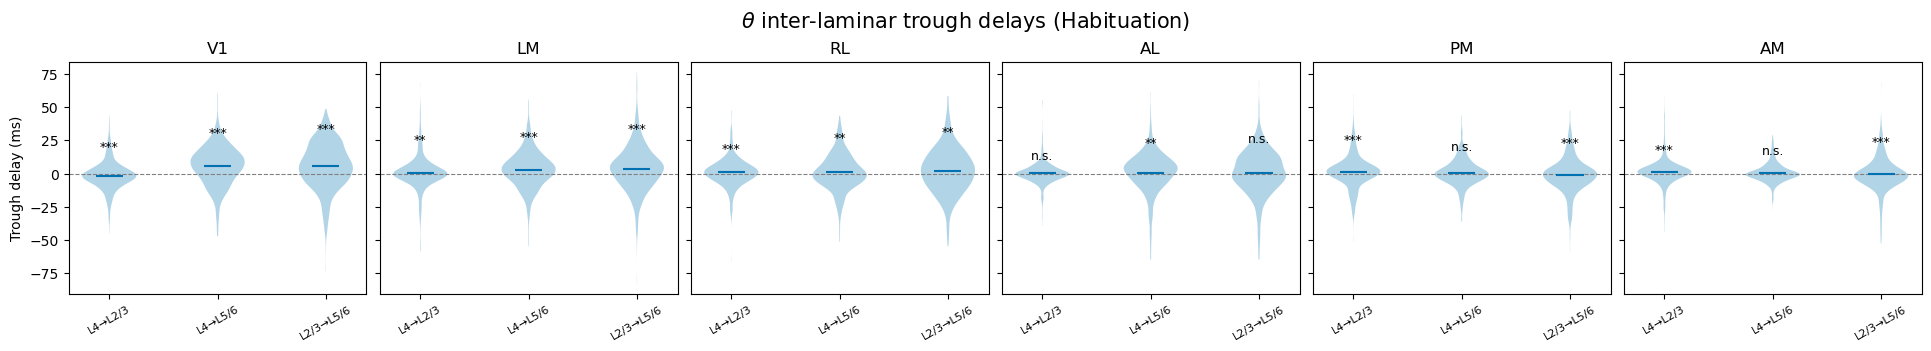

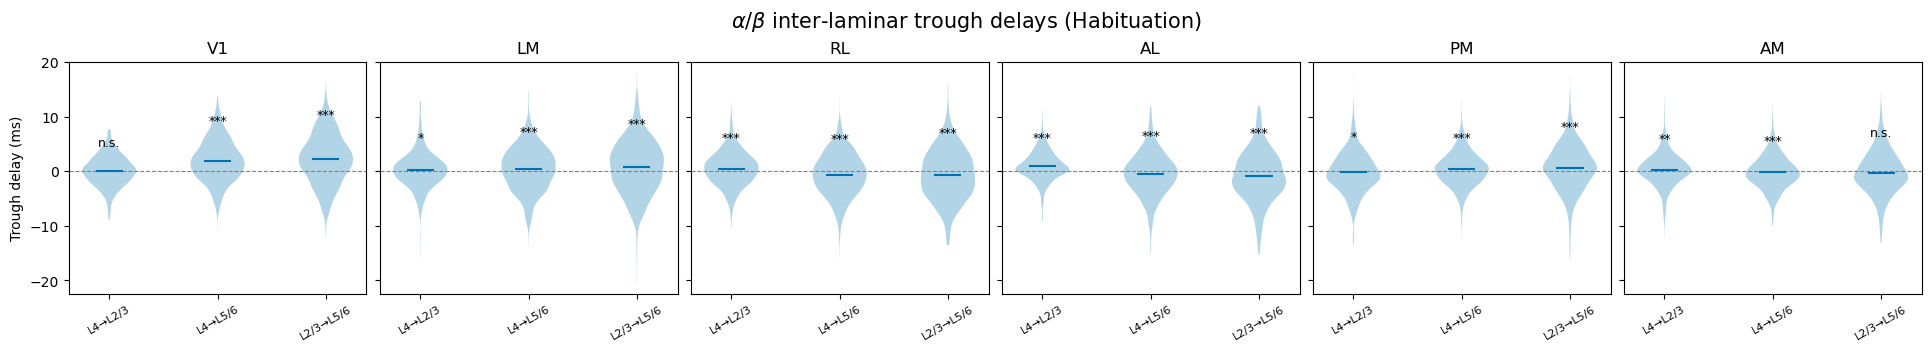

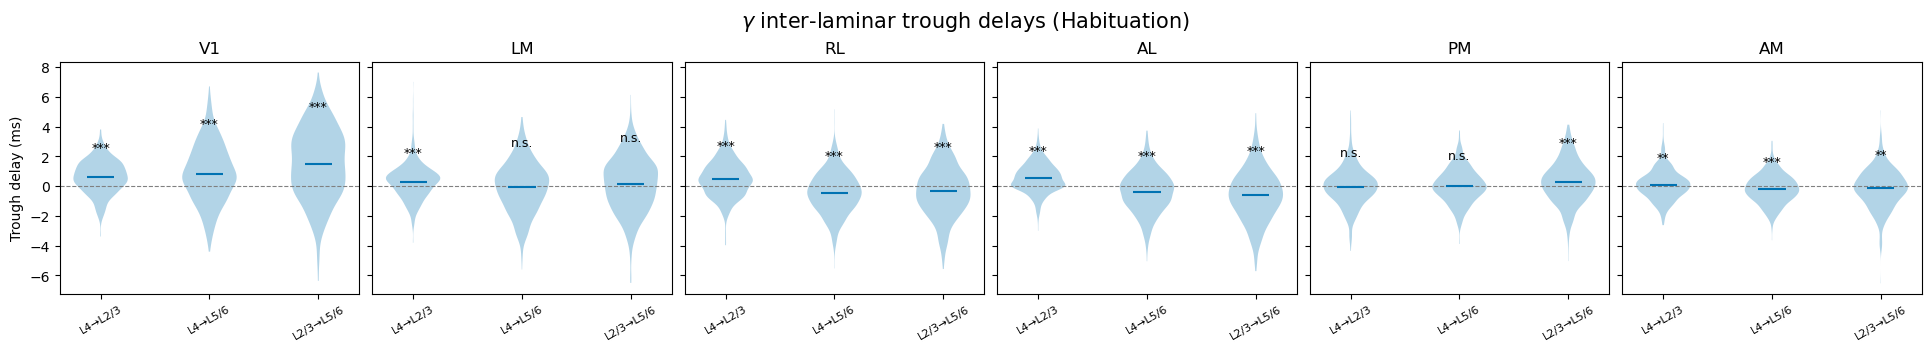

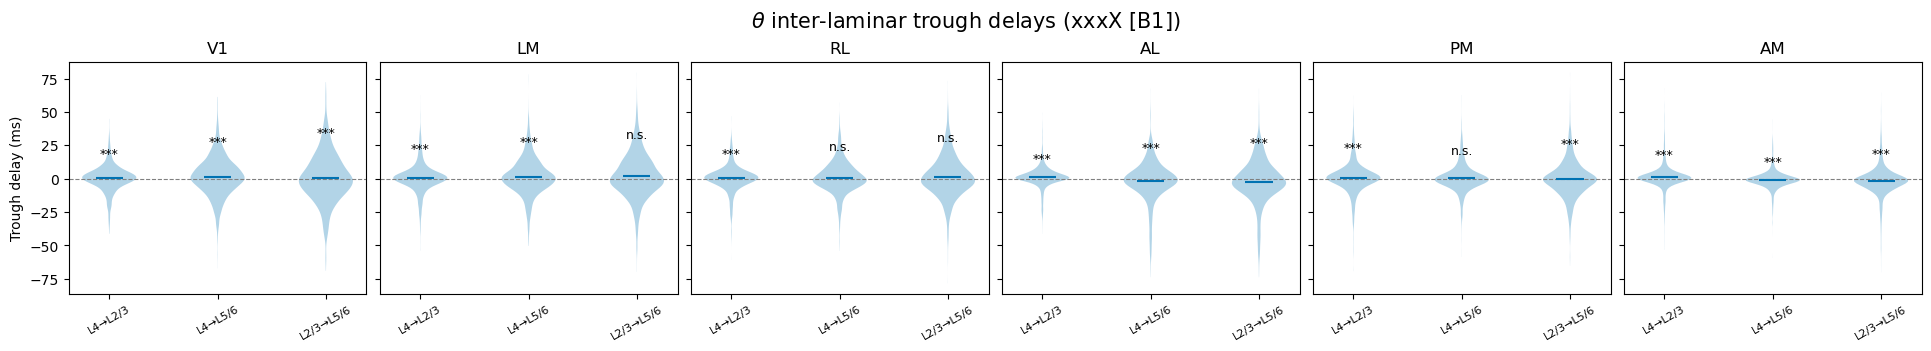

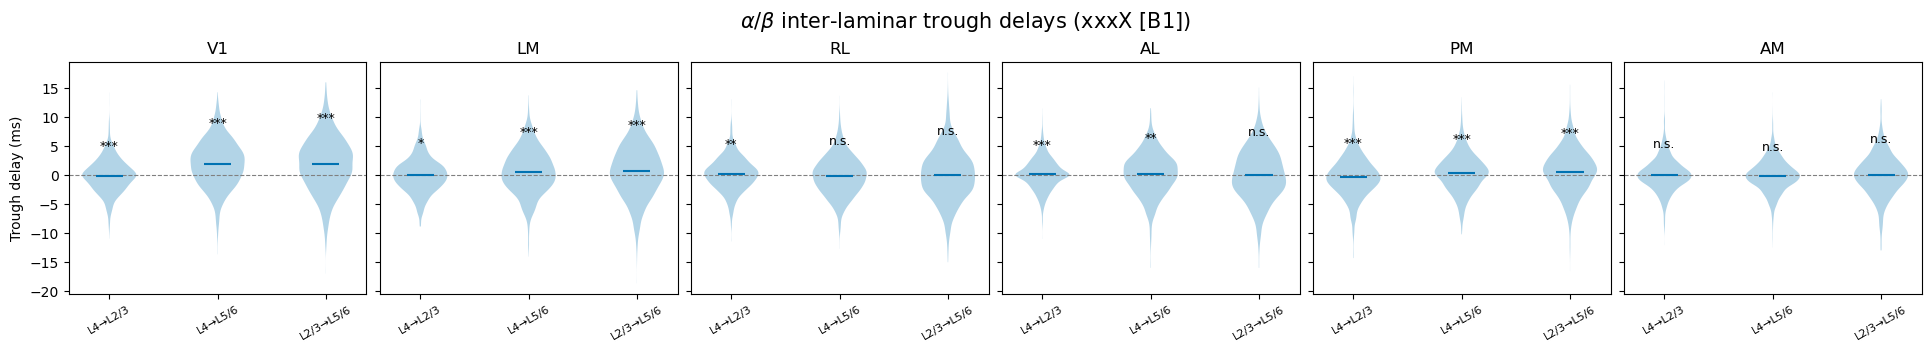

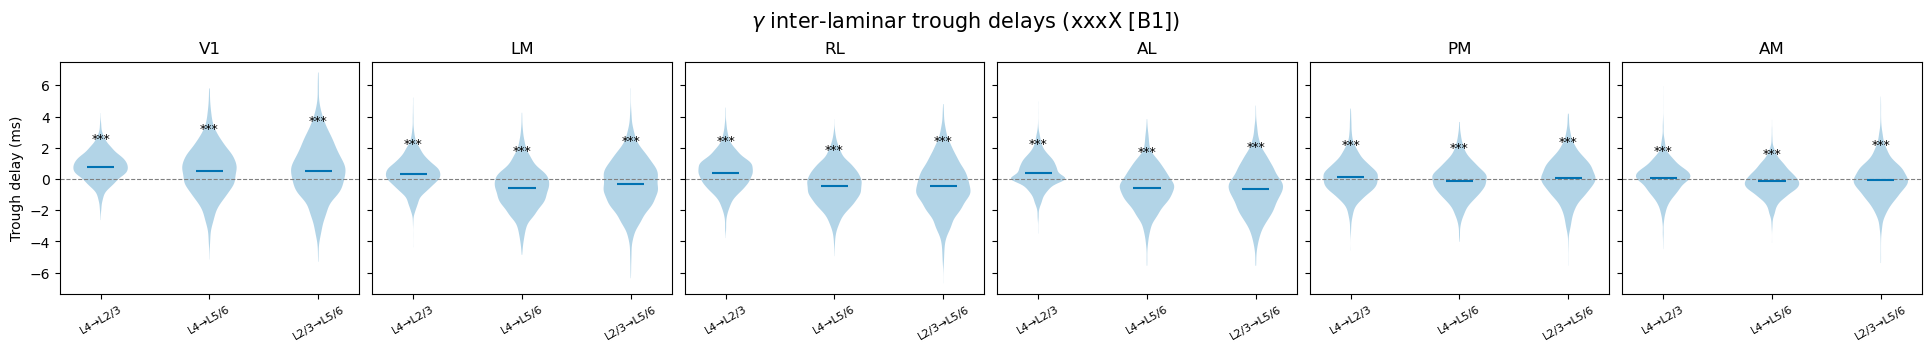

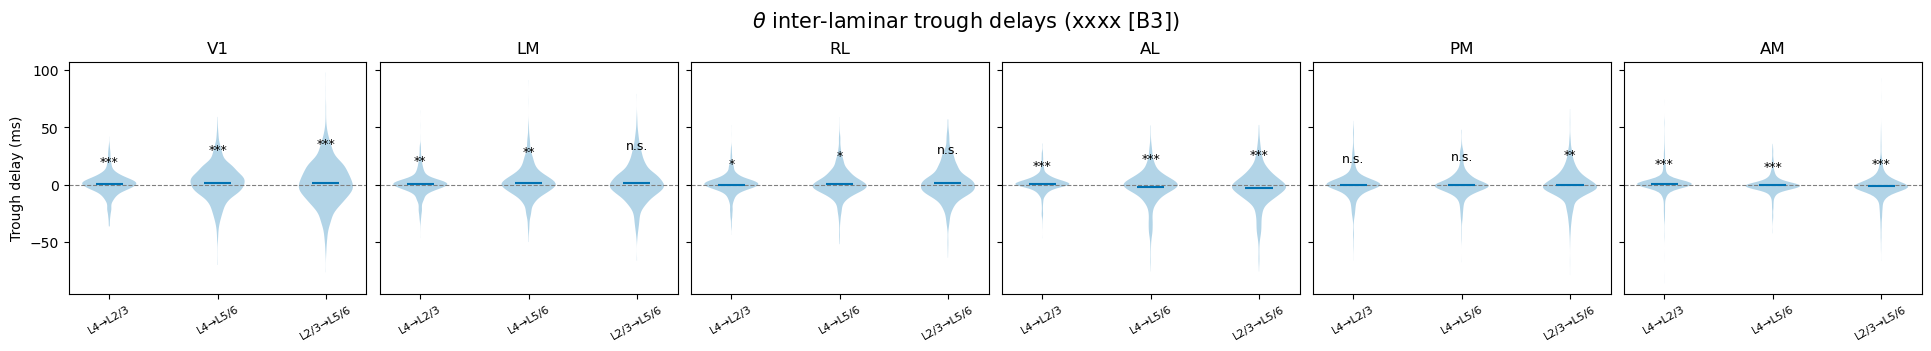

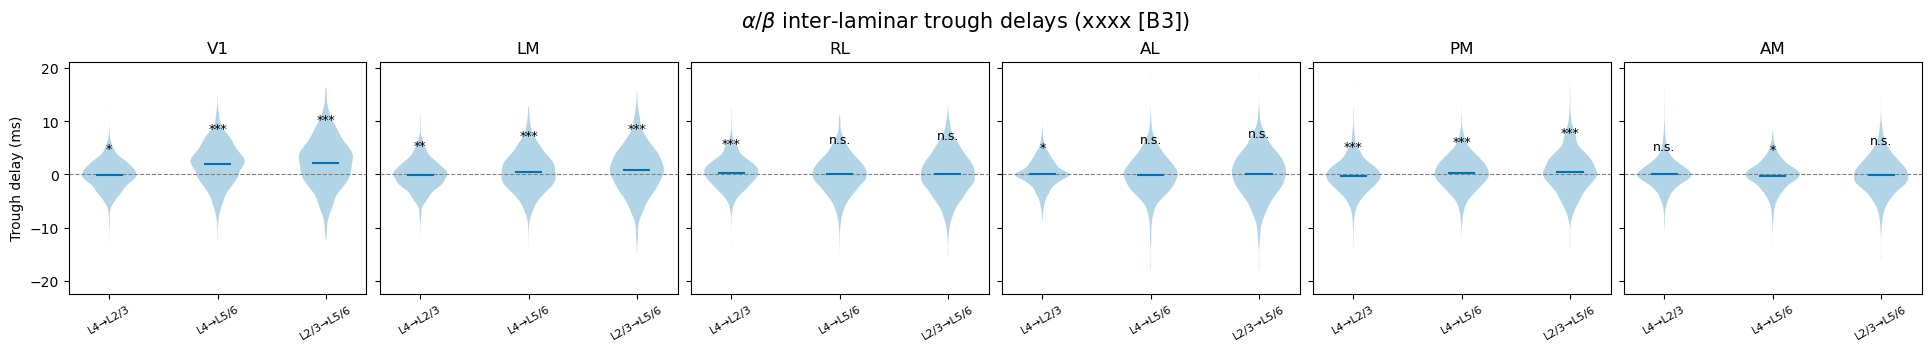

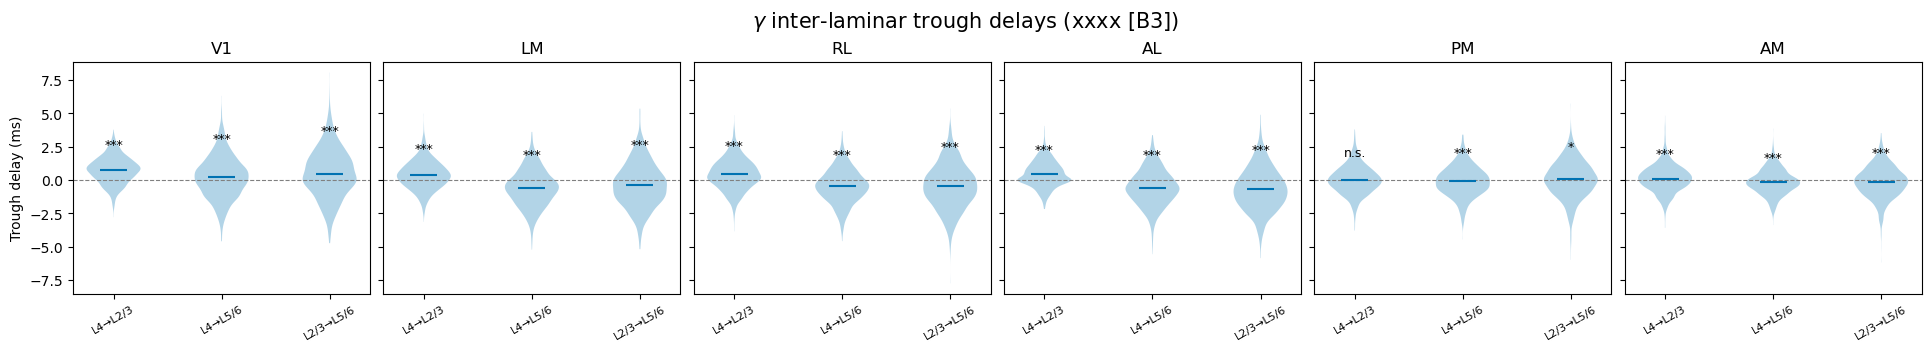

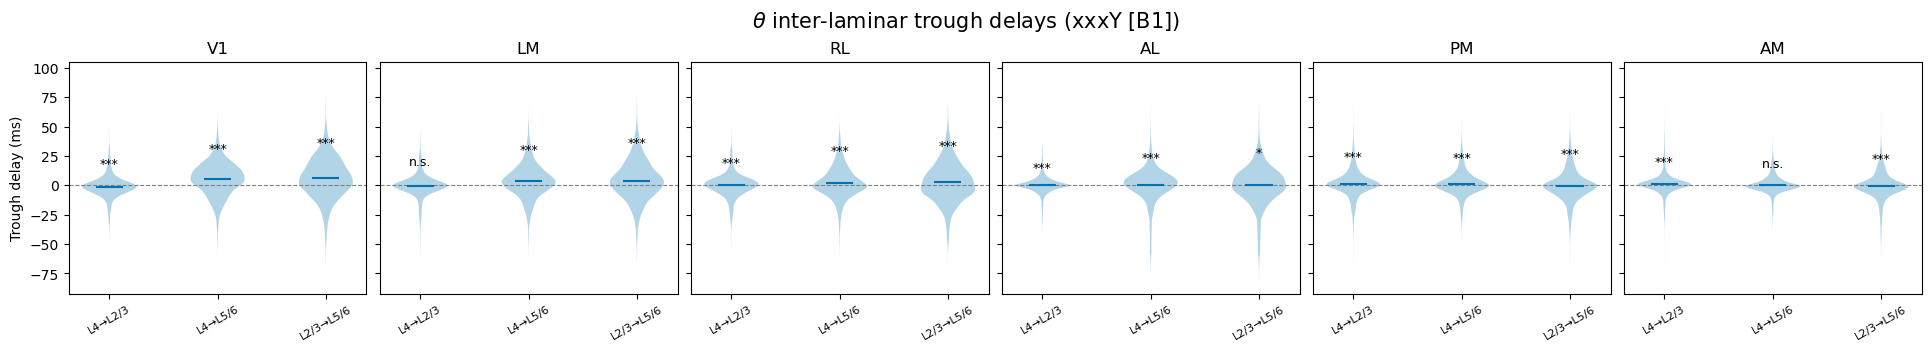

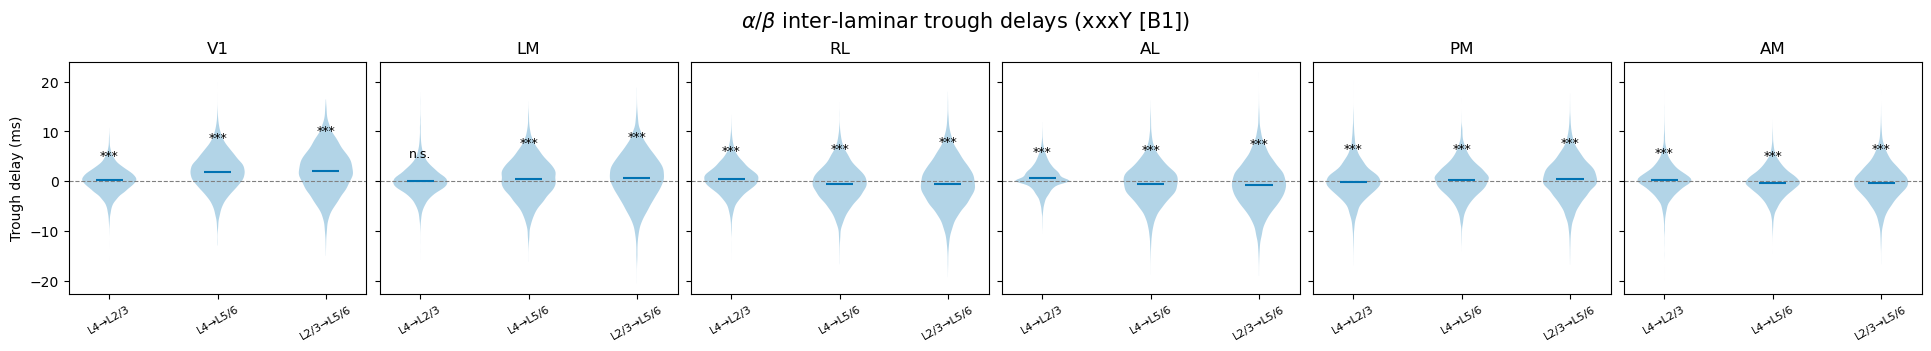

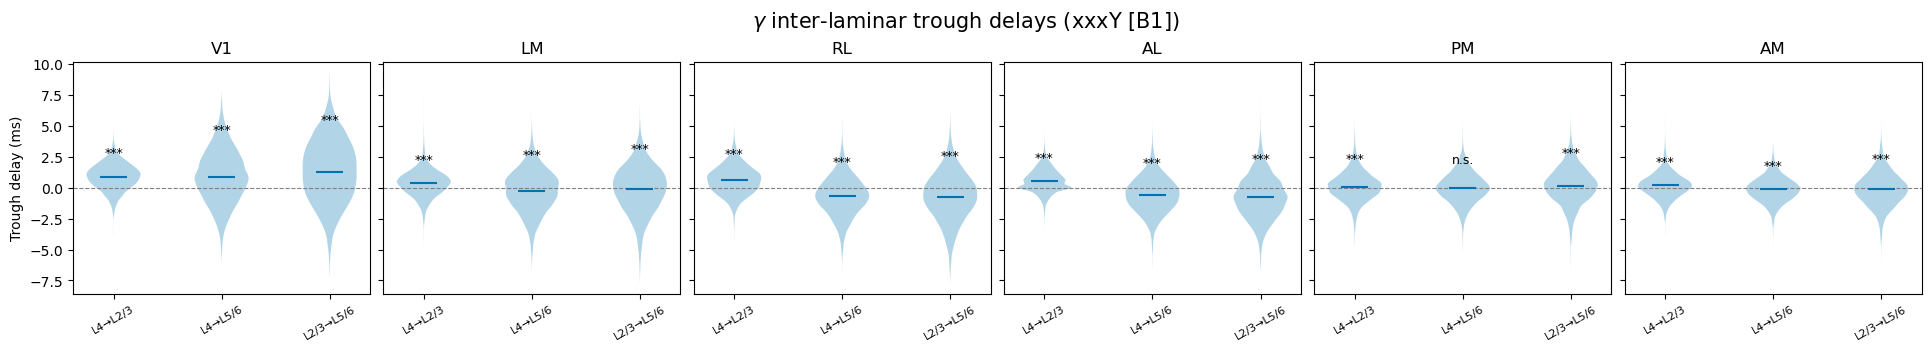

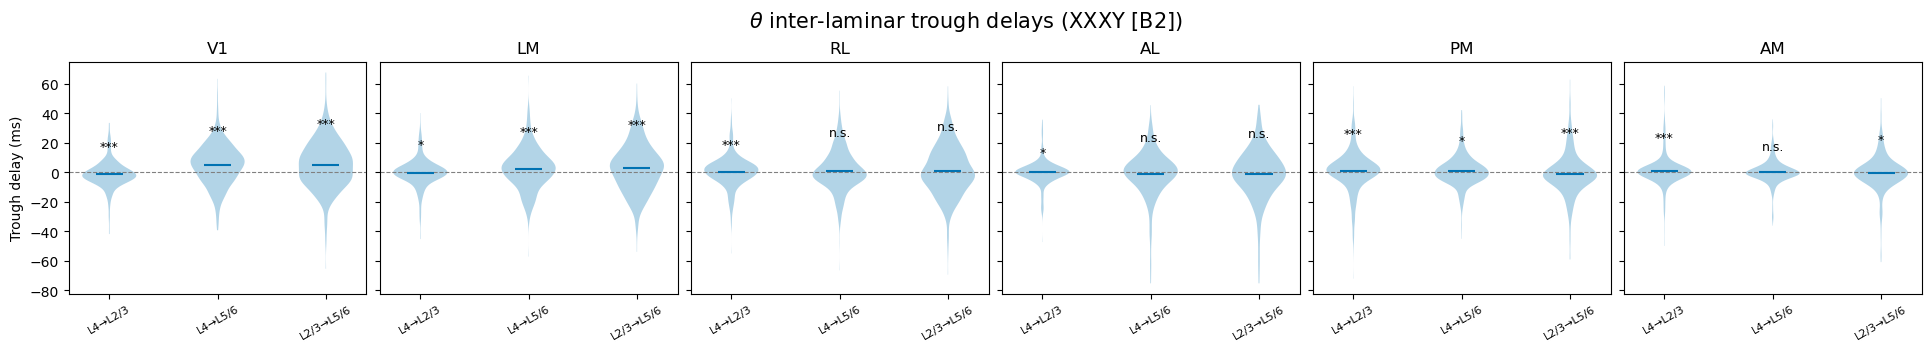

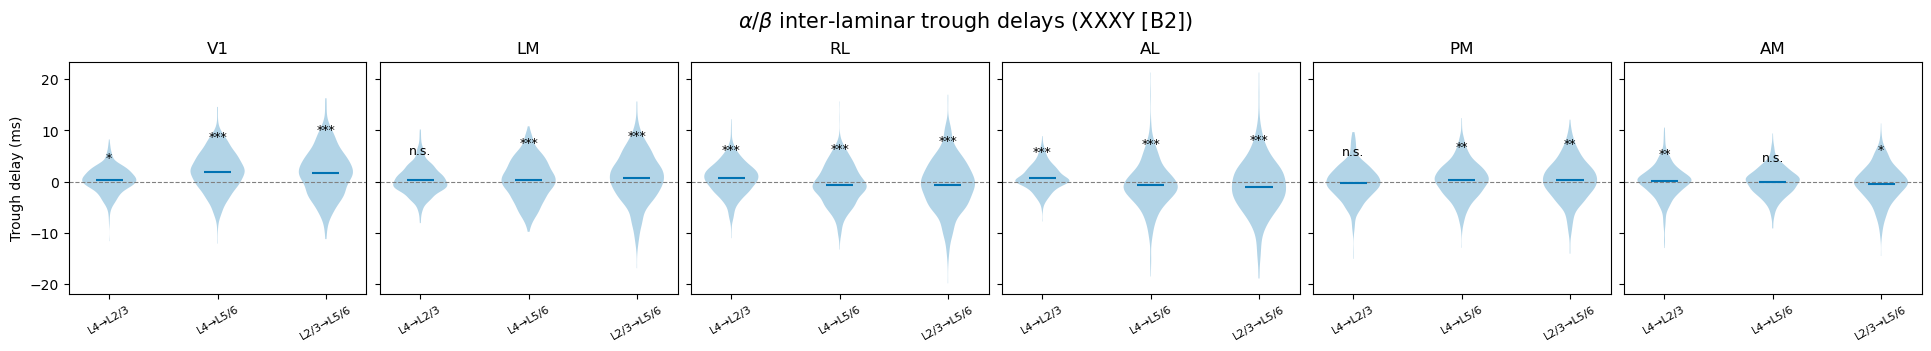

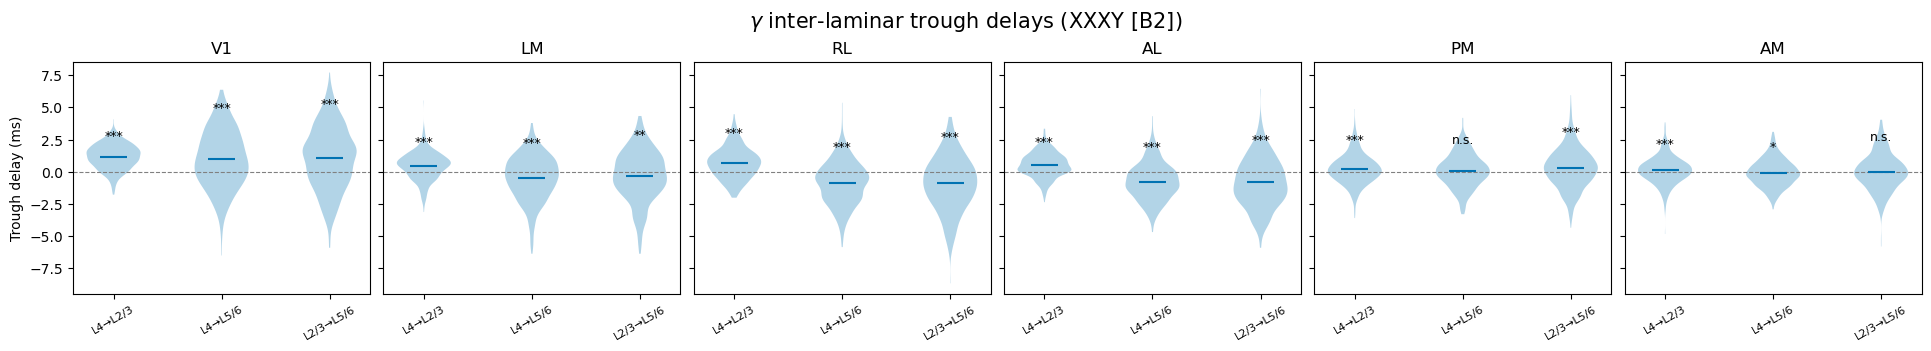

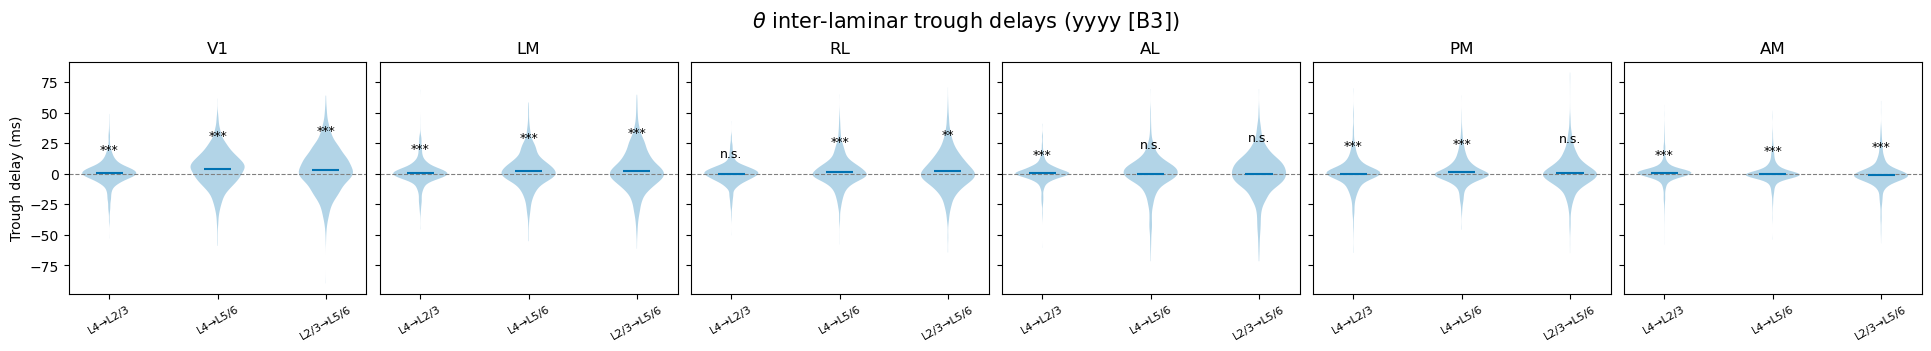

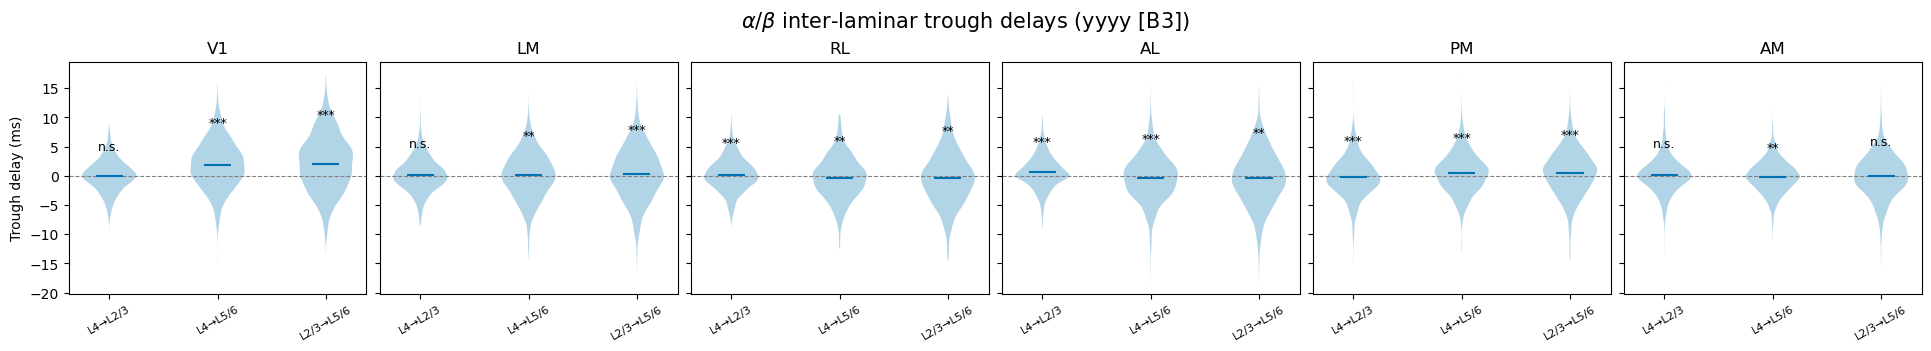

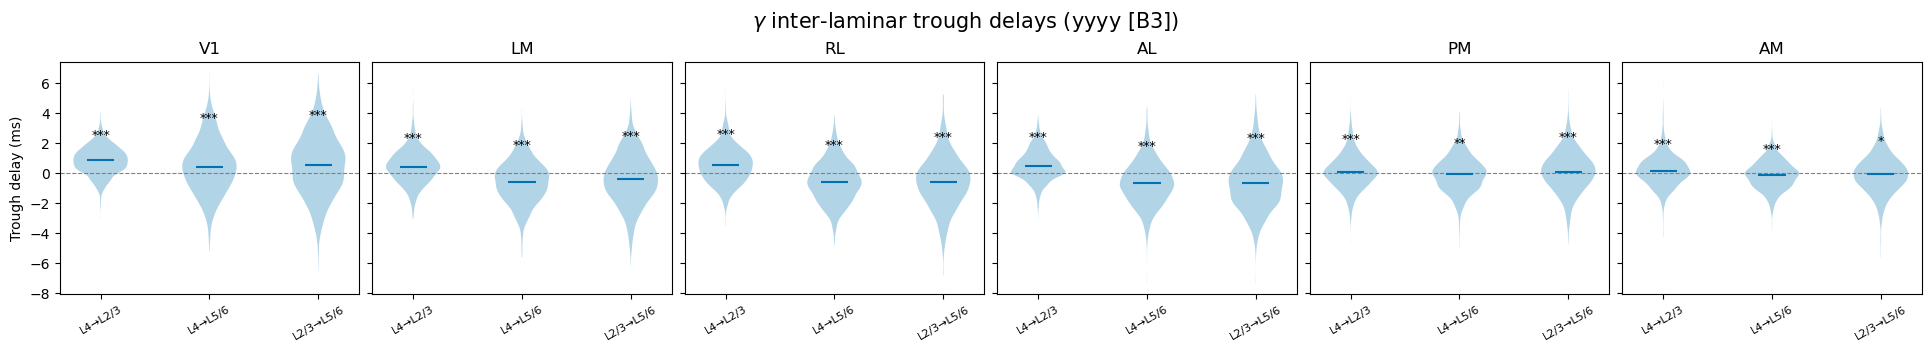

In [15]:
def plot_trough_delays(cond, band):
    stem, latex = BANDS[band]
    fig, axes = plt.subplots(1, len(ANATOMICAL_AREAS), figsize=(3.2 * len(ANATOMICAL_AREAS), 3.4),
                             sharey=True, layout="constrained")
    for ax, area in zip(axes, ANATOMICAL_AREAS):
        data = [delays[cond][band][area][p]["trough_per_trial_ms"] for p in LAYER_PAIRS]
        data = [d[~np.isnan(d)] for d in data]
        ax.axhline(0, color="gray", lw=0.8, ls="dashed")
        nonempty = [i for i, d in enumerate(data) if len(d) > 0]
        if nonempty:
            ax.violinplot([data[i] for i in nonempty],
                          positions=[i + 1 for i in nonempty],
                          showmeans=True, showextrema=False)
        for i, p in enumerate(LAYER_PAIRS):
            if len(data[i]) == 0:
                continue
            wp = delays[cond][band][area][p]["wilcoxon_p"]
            ax.annotate(stars(wp), (i + 1, np.nanpercentile(data[i], 95)),
                        ha="center", fontsize=9)
        ax.set_xticks(range(1, len(LAYER_PAIRS) + 1),
                      [pair_label(p) for p in LAYER_PAIRS], rotation=30, fontsize=8)
        ax.set_title(AREA_TITLES[area])
    axes[0].set_ylabel("Trough delay (ms)")
    fig.suptitle("%s inter-laminar trough delays (%s)" % (latex, CONDITION_TITLES[cond]), fontsize=15)
    return fig

for cond in CONDITIONS:
    os.makedirs("%s/laminar_delays" % cond, exist_ok=True)
    for band in BANDS:
        fig = plot_trough_delays(cond, band)
        fig.savefig("%s/laminar_delays/%s_trough_delays.svg" % (cond, BANDS[band][0]),
                    bbox_inches="tight")
        plt.show(); plt.close(fig)

## Summary: mean phase-difference delay across the hierarchy

Grouped bars of the circular phase-difference delay (± bootstrap 95% CI over trials) per area, one
row per condition. This is the propagation picture: e.g. feedforward gamma (L4→L2/3 positive) vs a
deep-layer lead in slower bands. Rayleigh significance (a consistent phase relationship exists) is
starred.

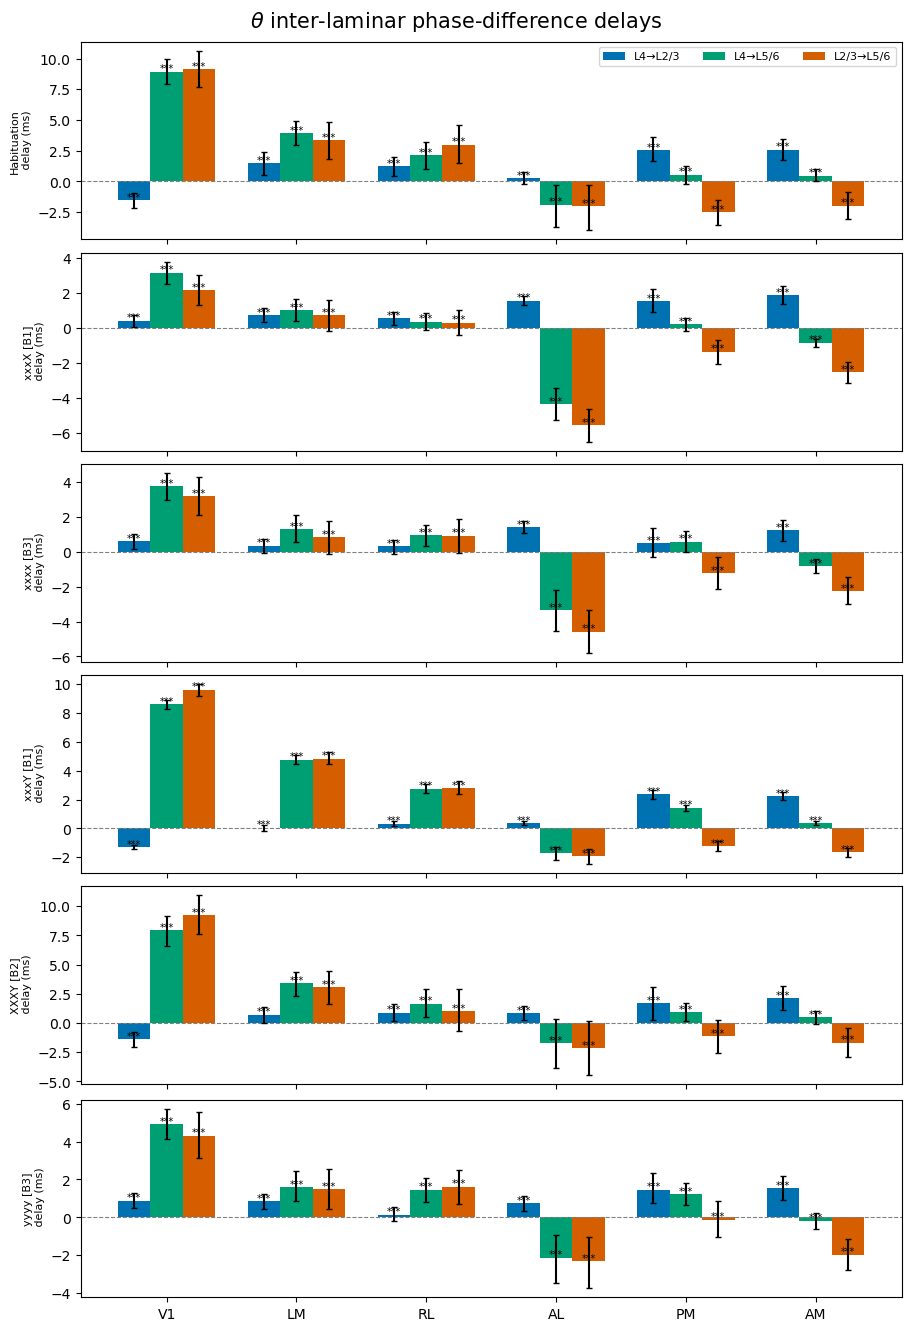

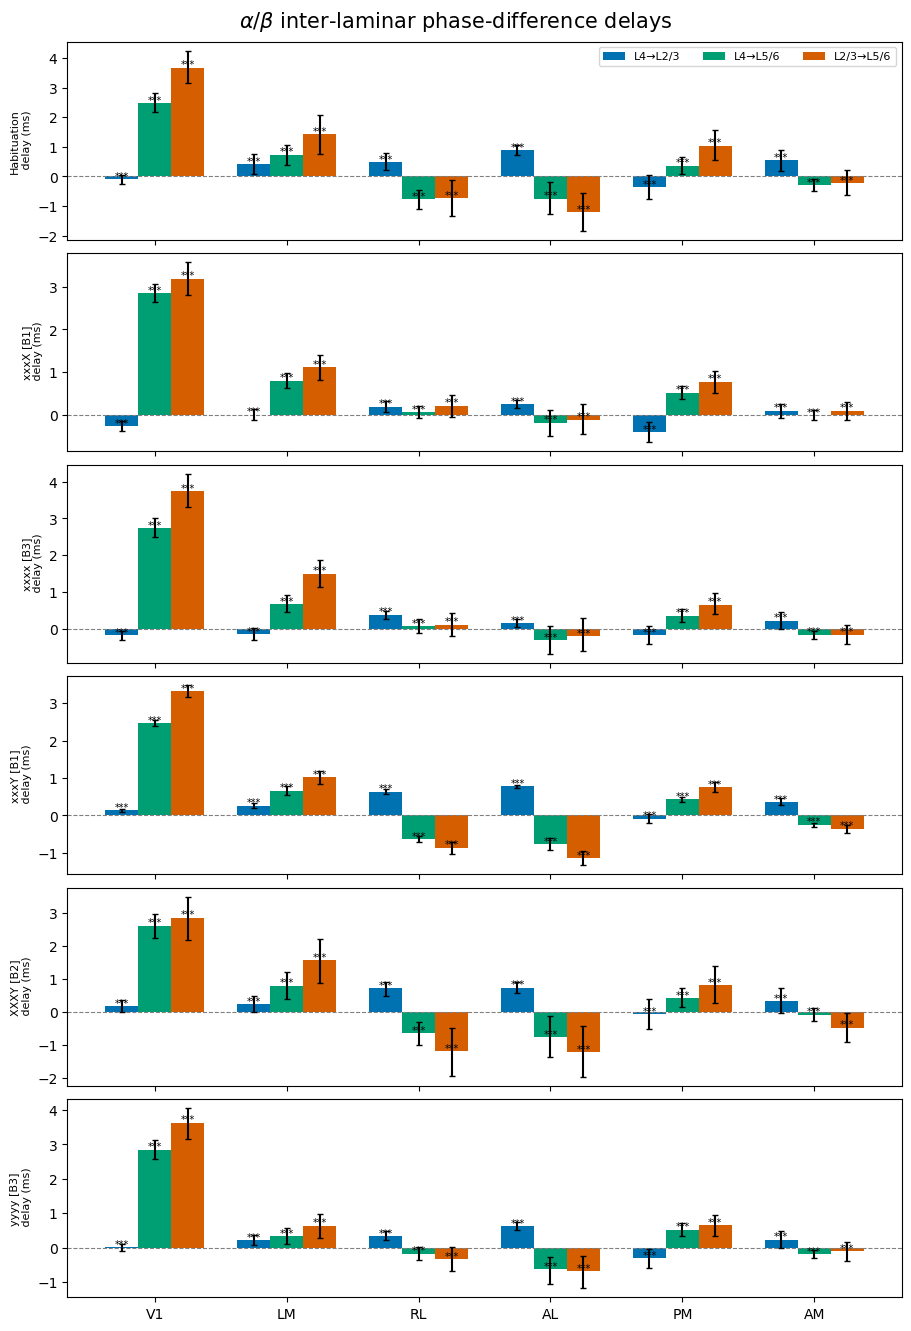

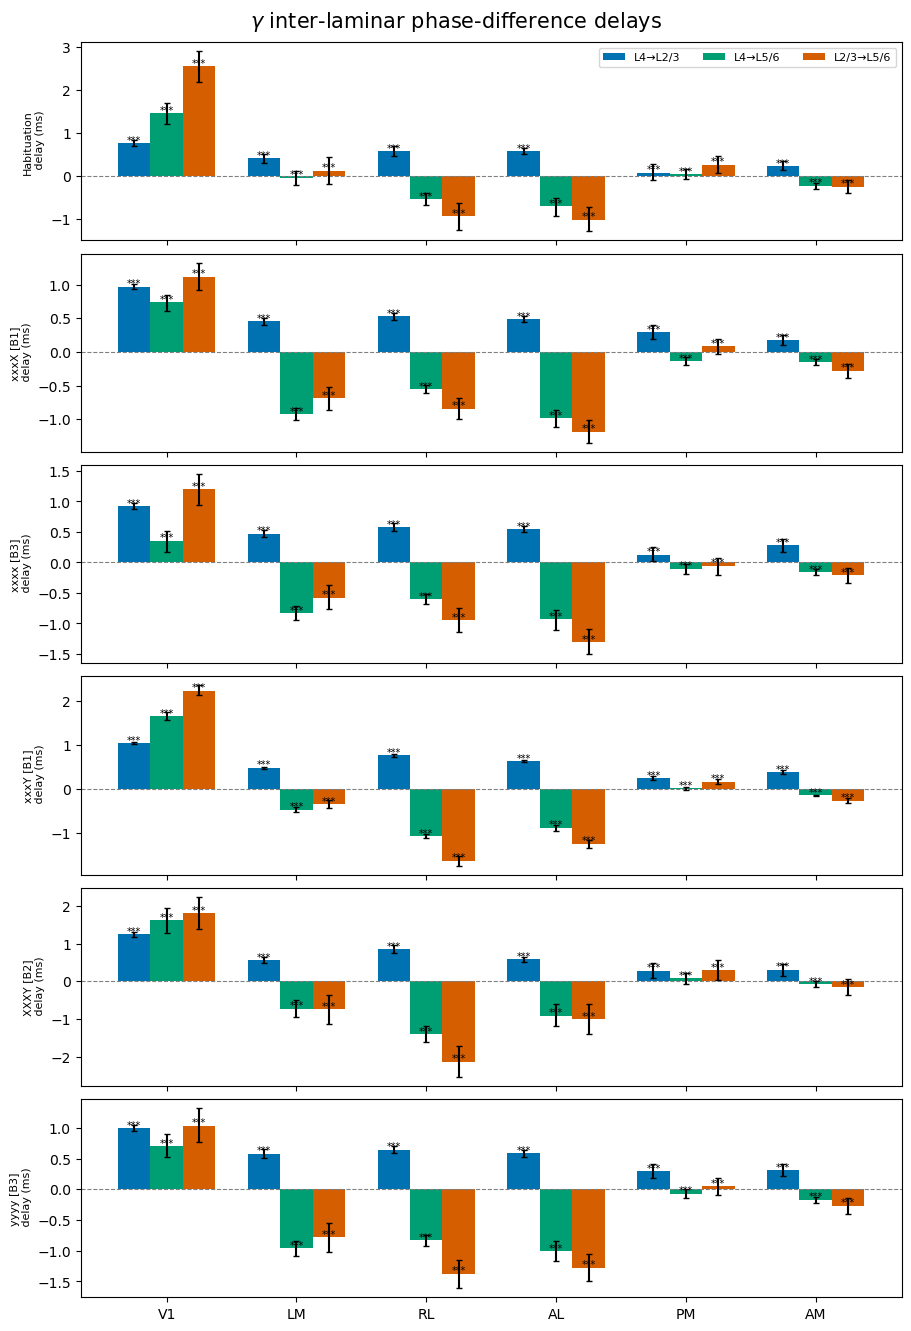

In [16]:
def bootstrap_ci(x, n_boot=1000, seed=0):
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = [np.mean(rng.choice(x, size=len(x), replace=True)) for _ in range(n_boot)]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

def plot_delay_summary(band):
    stem, latex = BANDS[band]
    fig, axes = plt.subplots(len(CONDITIONS), 1, figsize=(9, 2.2 * len(CONDITIONS)),
                             sharex=True, layout="constrained")
    width = 0.25
    xs = np.arange(len(ANATOMICAL_AREAS))
    for ax, cond in zip(axes, CONDITIONS):
        ax.axhline(0, color="gray", lw=0.8, ls="dashed")
        for j, pair in enumerate(LAYER_PAIRS):
            means, los, his, marks = [], [], [], []
            for area in ANATOMICAL_AREAS:
                d = delays[cond][band][area][pair]
                dm = d["phase_delay_ms"]
                means.append(np.nanmean(dm))
                lo, hi = bootstrap_ci(dm)
                los.append(np.nanmean(dm) - lo); his.append(hi - np.nanmean(dm))
                marks.append(stars(d["rayleigh_p"]))
            bars = ax.bar(xs + (j - 1) * width, means, width, yerr=[los, his],
                          capsize=2, label=pair_label(pair))
            for x, m, s in zip(xs, means, marks):
                if s and s != "n.s.":
                    ax.annotate(s, (x + (j - 1) * width, m), ha="center", fontsize=7)
        ax.set_ylabel("%s\n delay (ms)" % CONDITION_TITLES[cond], fontsize=8)
    axes[-1].set_xticks(xs, [AREA_TITLES[a] for a in ANATOMICAL_AREAS])
    axes[0].legend(ncol=3, fontsize=8, loc="upper right")
    fig.suptitle("%s inter-laminar phase-difference delays" % latex, fontsize=15)
    return fig

os.makedirs("laminar_delays", exist_ok=True)
for band in BANDS:
    fig = plot_delay_summary(band)
    fig.savefig("laminar_delays/summary_%s.svg" % BANDS[band][0], bbox_inches="tight")
    plt.show(); plt.close(fig)

## CSD sink-latency corroboration

Independent check via the van Kerkoerle construction: trigger the full-probe laminar CSD on the L4
trough, average over cycles, and read the current **sink** (most negative CSD) latency in each layer.
The cross-layer sink timing should track the phase delays. We bootstrap over cycles for a CI on each
latency.

In [17]:
def layer_csd(oddballs, area, l4_phase_sig, period_s):
    """Per-layer L4-trough-triggered CSD traces (mean over cycles) + per-cycle traces for bootstrap."""
    osc = oddballs.signals[area].epoch_oscillations(period_s * pq.second, l4_phase_sig)
    csd = osc.downsample(4).current_source_density(depth_column="vertical", method=None)
    times = csd.times.rescale("ms").magnitude
    data = csd.data.magnitude                            # (channels, time, cycles)
    per_cycle, mean_trace = {}, {}
    for layer, selector in LAYERS.items():
        mask = np.array([selector(loc) for loc in csd.channels.location.values])
        if mask.sum() == 0:
            continue
        lc = data[mask].mean(axis=0)                     # (time, cycles)
        per_cycle[layer] = lc
        mean_trace[layer] = lc.mean(axis=1)
    return times, mean_trace, per_cycle

def sink_latency(times, trace, period_s):
    window = np.abs(times) <= (period_s / 1.5) / 2 * 1000.0   # +-half a cycle around the trough
    idx = np.where(window)[0]
    return times[idx[np.argmin(trace[idx])]]

def sink_latency_ci(times, per_cycle_layer, period_s, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    n = per_cycle_layer.shape[1]
    lat = [sink_latency(times, per_cycle_layer[:, rng.integers(0, n, n)].mean(axis=1), period_s)
           for _ in range(n_boot)]
    return np.percentile(lat, 2.5), np.percentile(lat, 97.5)

csd_delays = {cond: {band: {} for band in BANDS} for cond in CONDITIONS}

for cond in CONDITIONS:
    logging.info("CSD sink latencies: loading LFPs for %s", cond)
    sampling = epych.recording.Sampling.unpickle("/mnt/data/000253/grandcat_%s" % cond)
    oddballs = sampling.smap(oddball)
    del sampling
    oddballs._signals = {k: v for k, v in oddballs.signals.items() if k in ANATOMICAL_AREAS}
    for band in BANDS:
        period_s = 1.5 / band_center(band)
        l4 = layer_phases(oddballs, cond, band, "L4")
        for area in ANATOMICAL_AREAS:
            times, mean_trace, per_cycle = layer_csd(oddballs, area, l4.signals[area], period_s)
            latency = {ly: sink_latency(times, tr, period_s) for ly, tr in mean_trace.items()}
            ci = {ly: sink_latency_ci(times, per_cycle[ly], period_s) for ly in mean_trace}
            csd_delays[cond][band][area] = {"times": times, "traces": mean_trace,
                                            "latency": latency, "latency_ci": ci}
        del l4
    logging.info("  CSD latencies for %s done", cond)

INFO:root:CSD sink latencies: loading LFPs for lonaive
INFO:root:  CSD latencies for lonaive done
INFO:root:CSD sink latencies: loading LFPs for go_gloexp
INFO:root:  CSD latencies for go_gloexp done
INFO:root:CSD sink latencies: loading LFPs for go_seqctl
INFO:root:  CSD latencies for go_seqctl done
INFO:root:CSD sink latencies: loading LFPs for lo_gloexp
INFO:root:  CSD latencies for lo_gloexp done
INFO:root:CSD sink latencies: loading LFPs for lo_rndctl
INFO:root:  CSD latencies for lo_rndctl done
INFO:root:CSD sink latencies: loading LFPs for igo_seqctl
INFO:root:  CSD latencies for igo_seqctl done


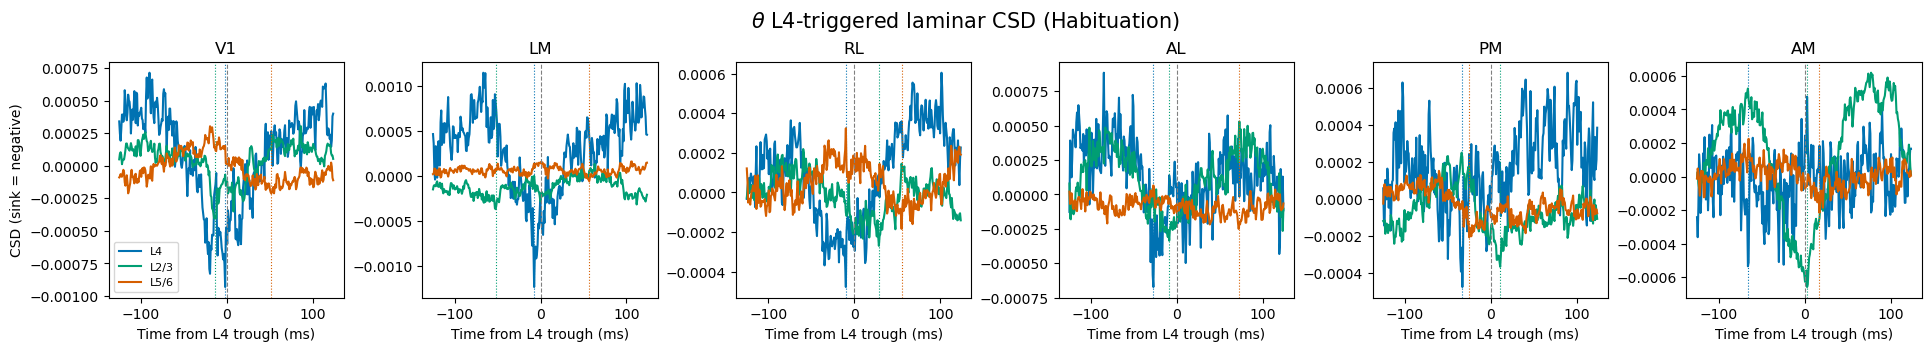

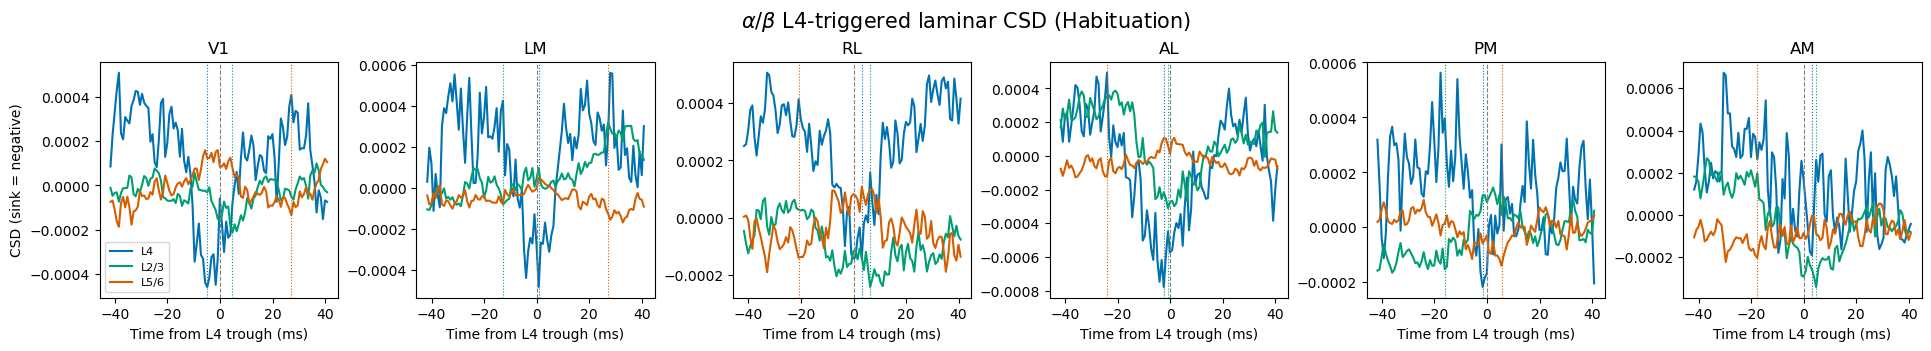

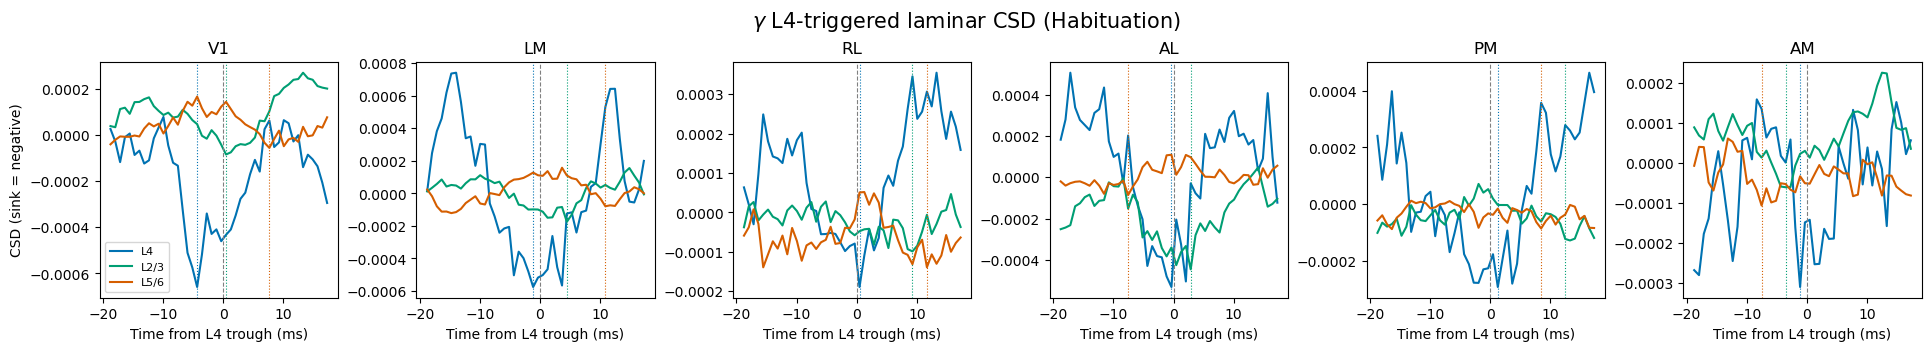

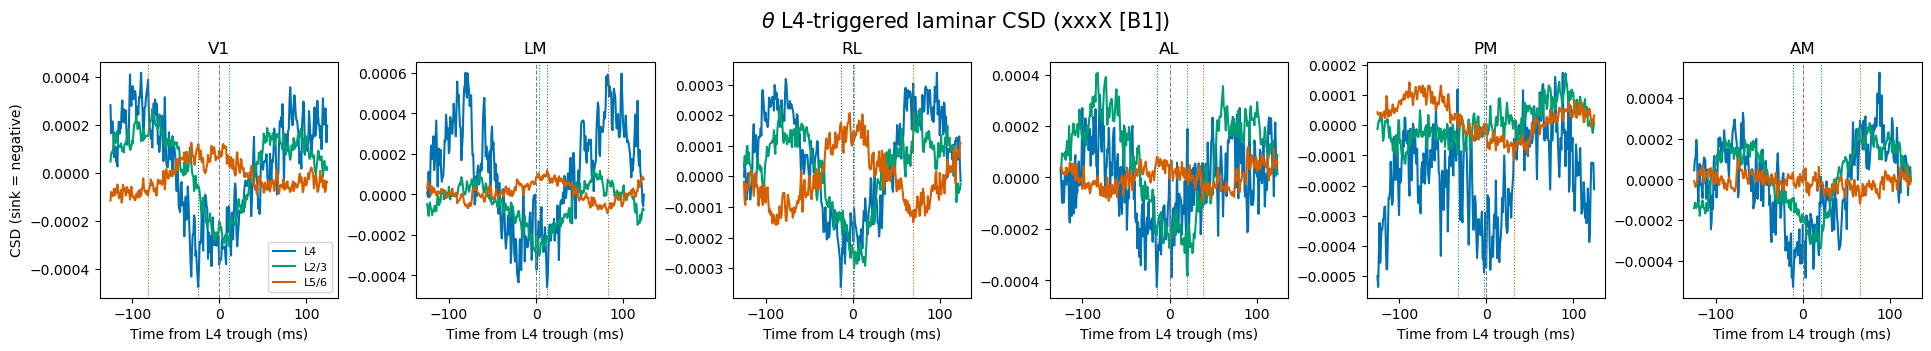

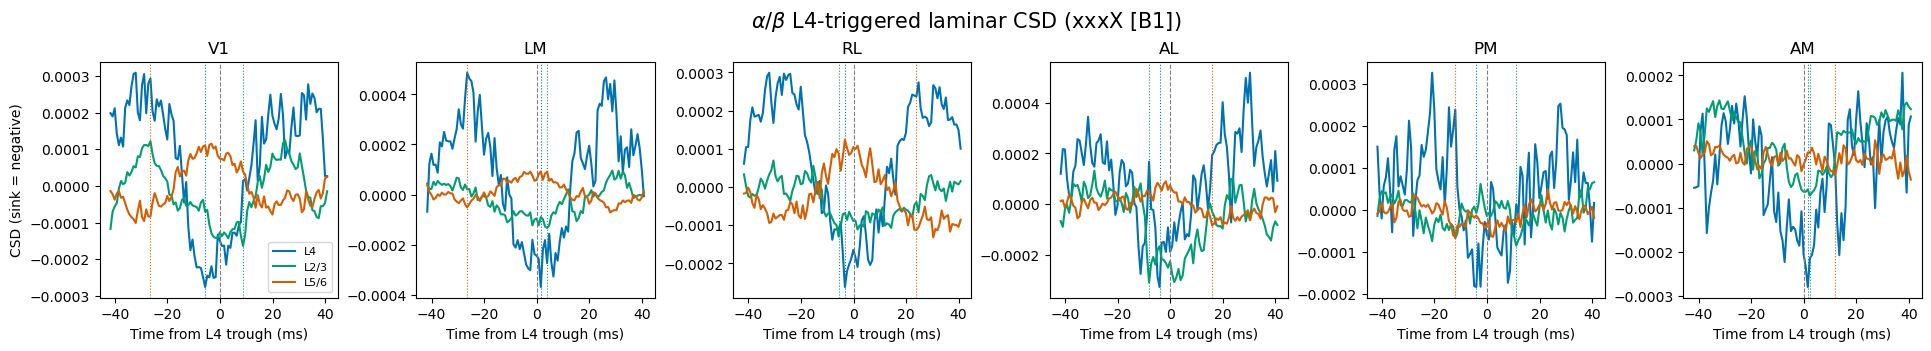

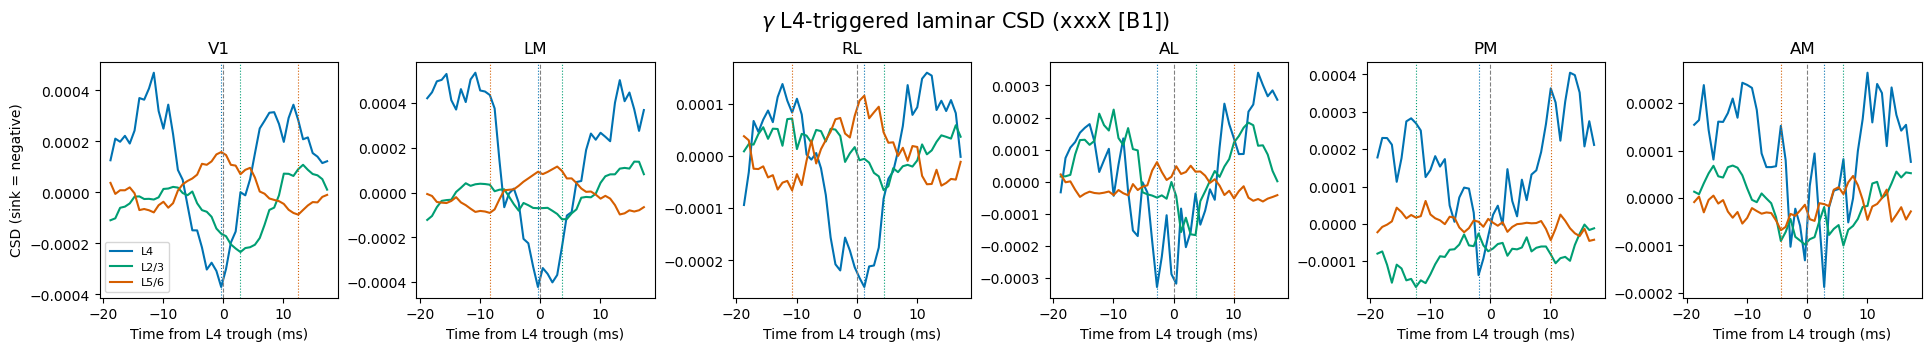

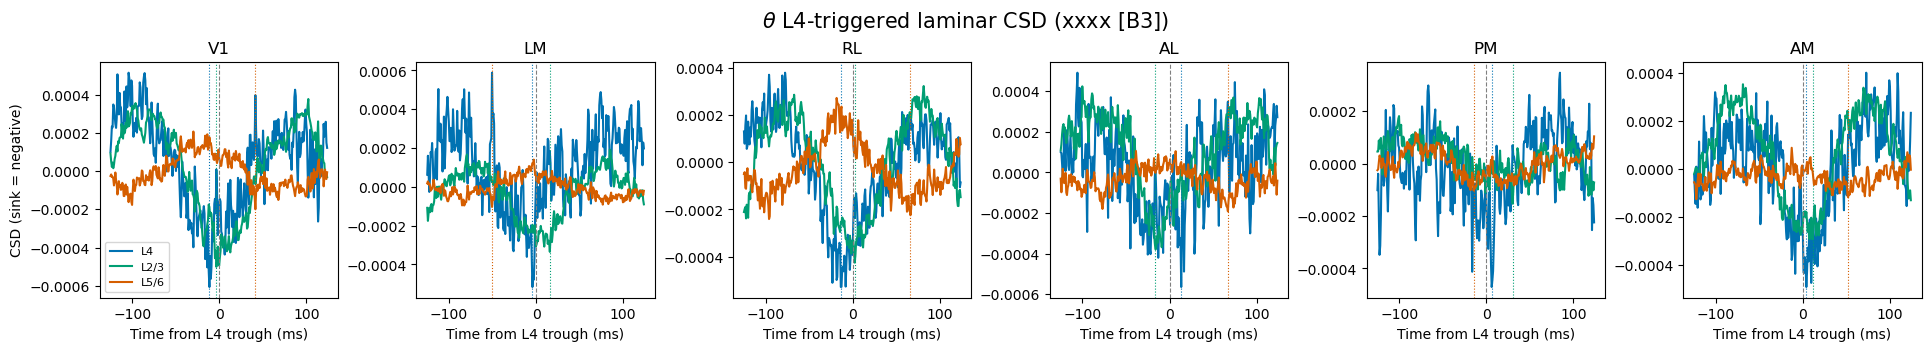

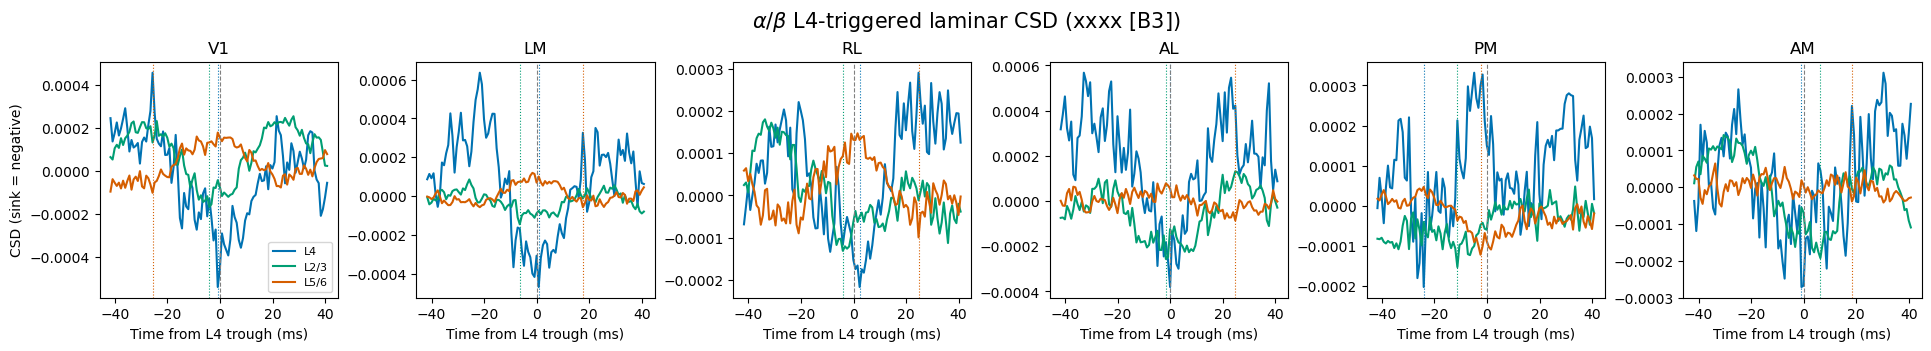

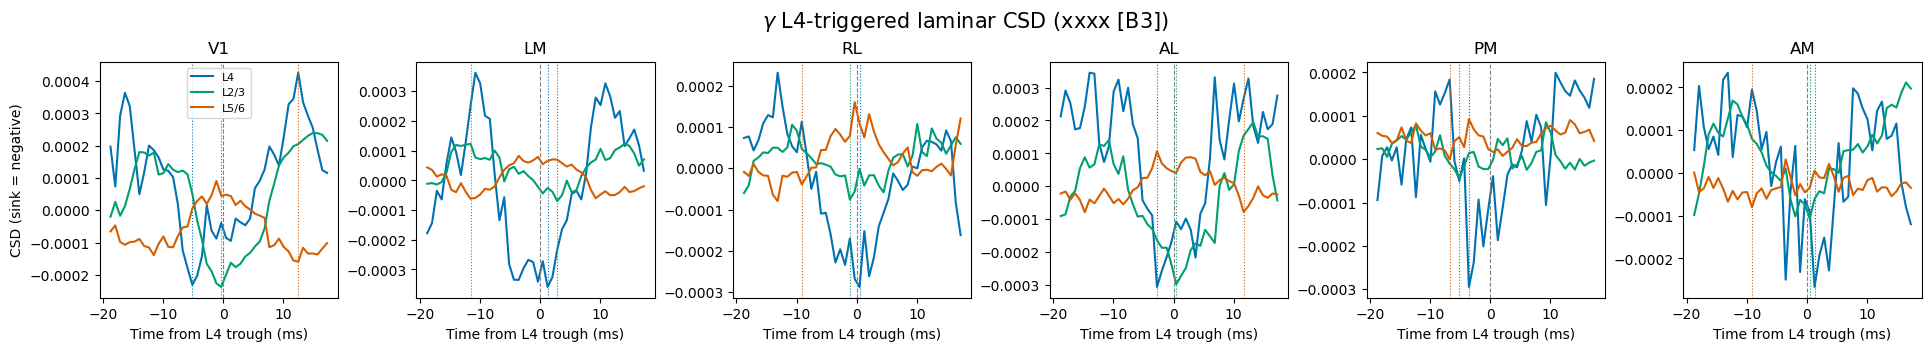

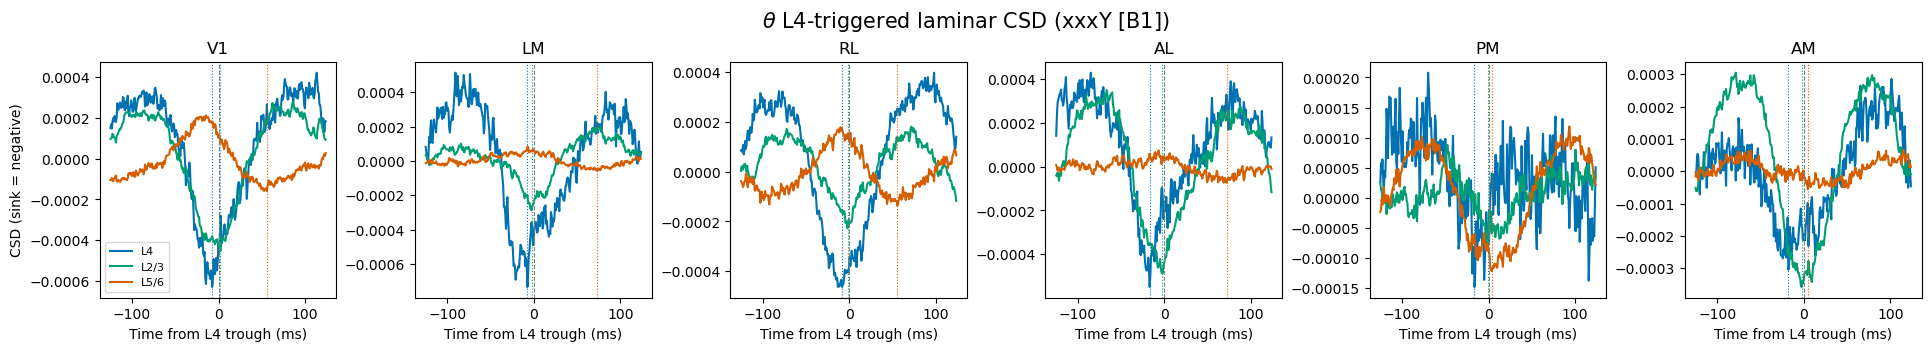

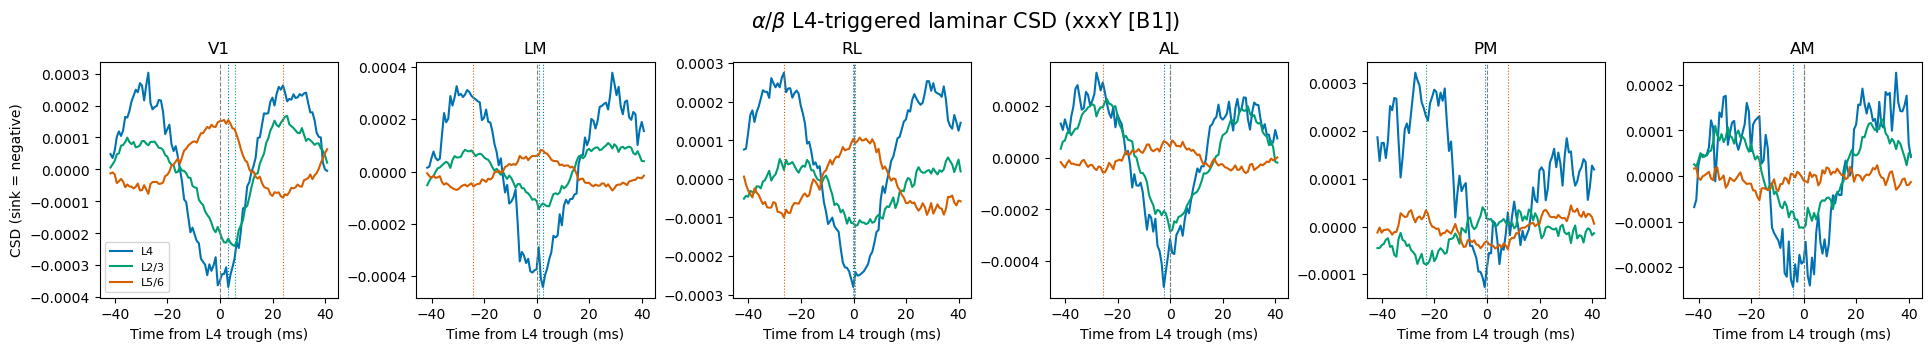

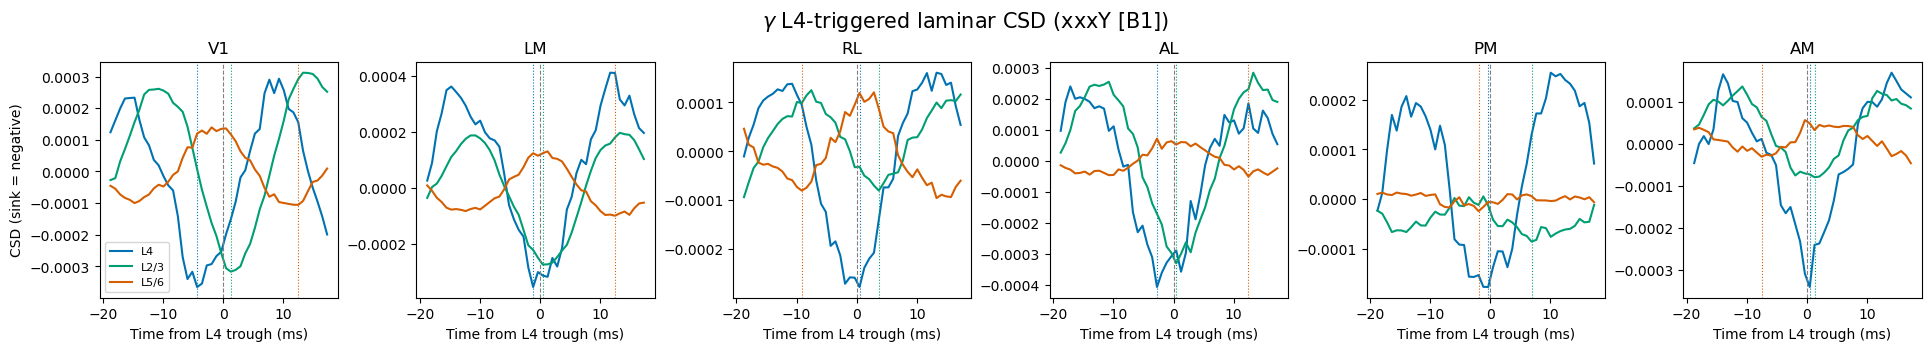

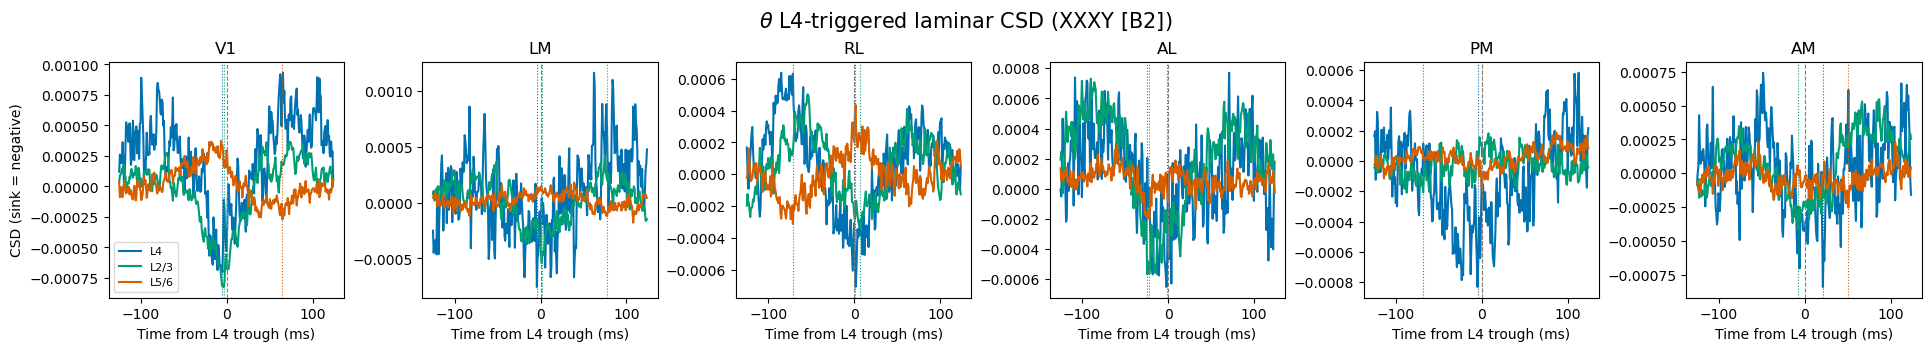

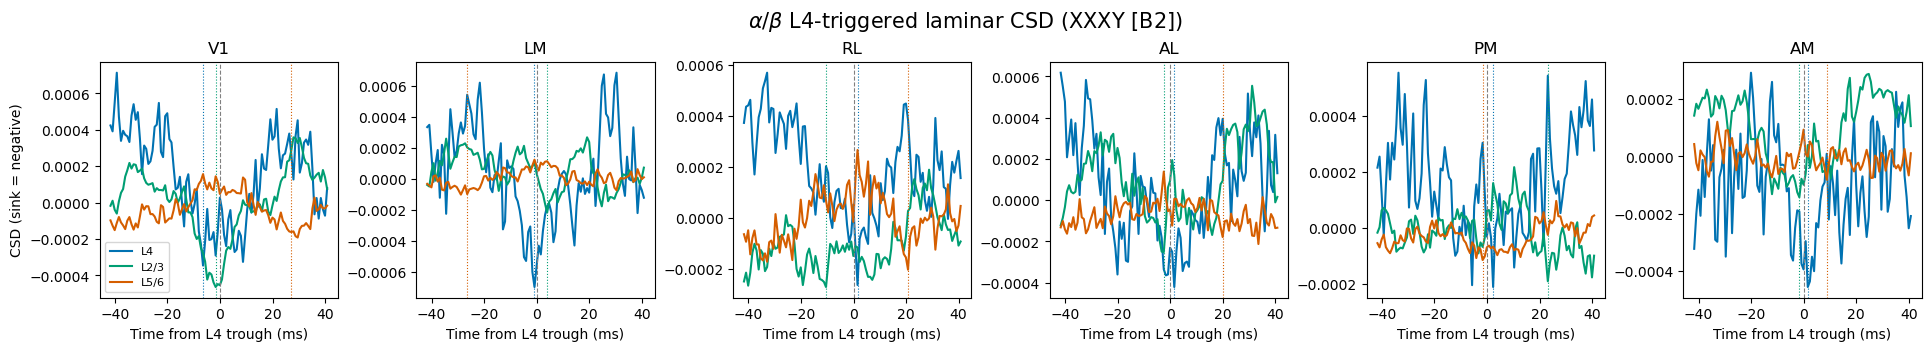

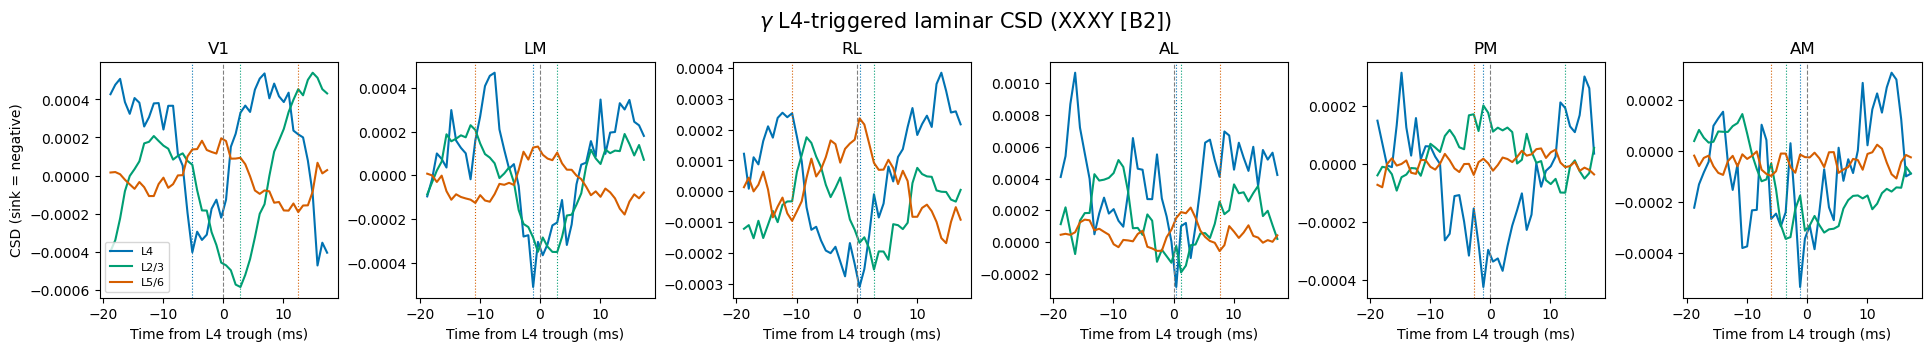

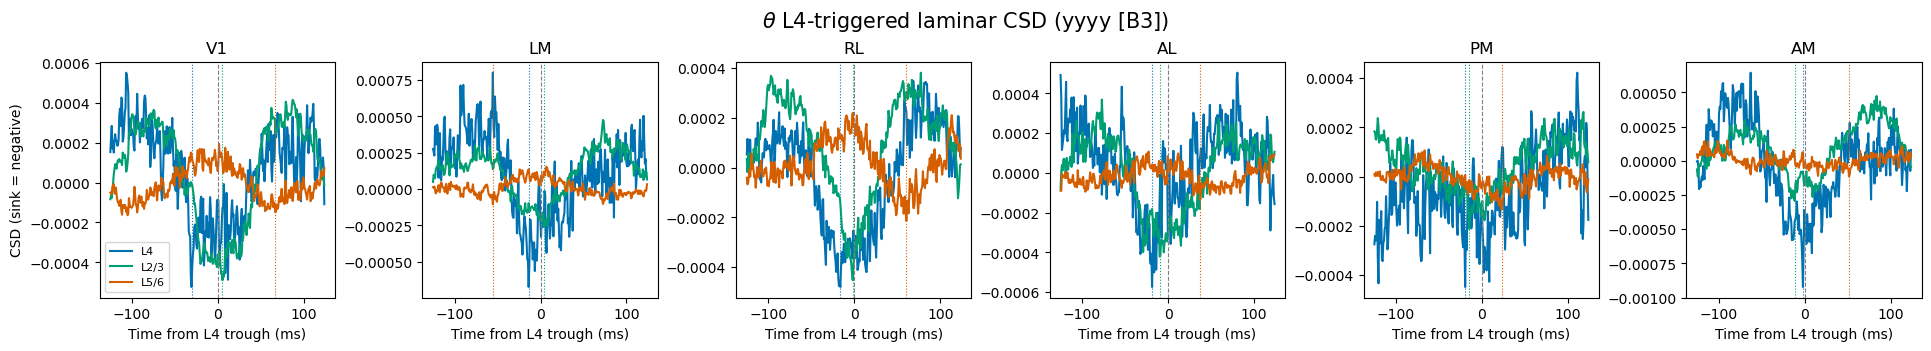

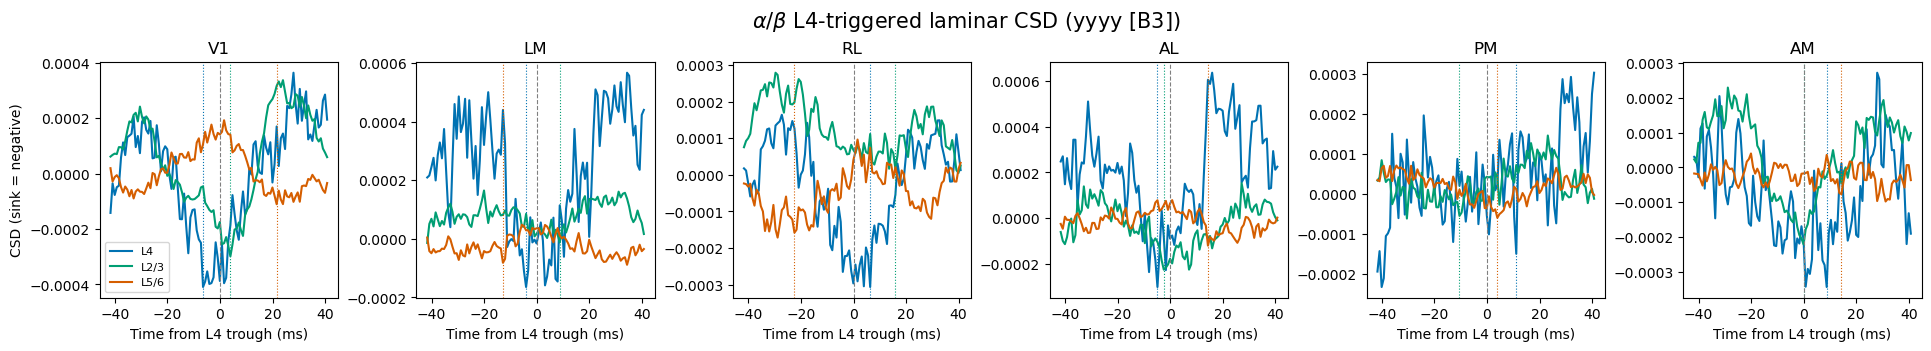

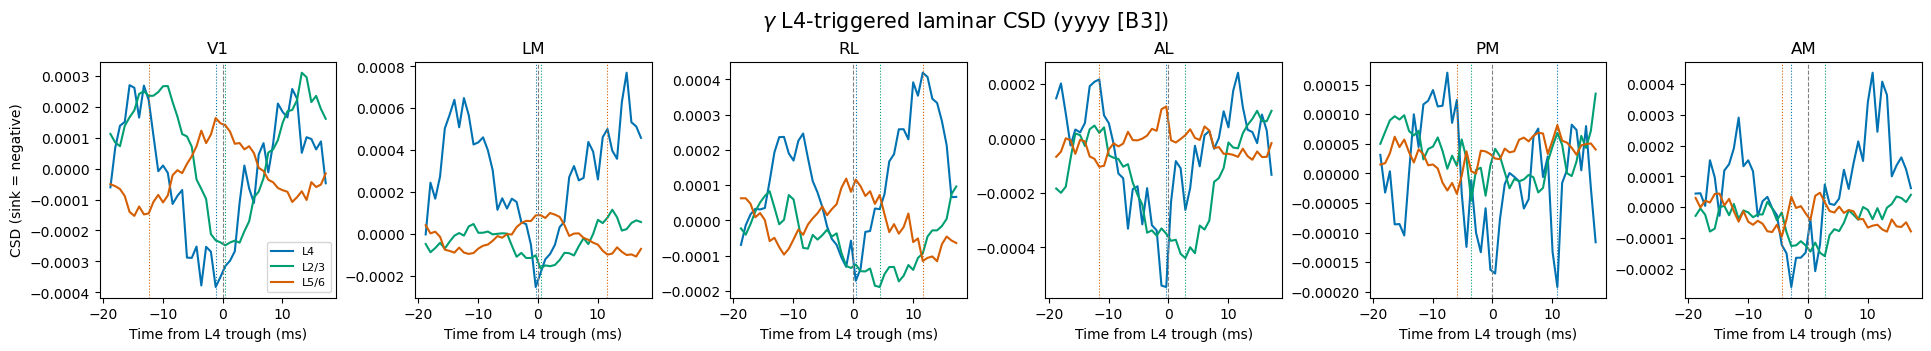

In [18]:
def plot_csd_traces(cond, band):
    stem, latex = BANDS[band]
    fig, axes = plt.subplots(1, len(ANATOMICAL_AREAS), figsize=(3.2 * len(ANATOMICAL_AREAS), 3.4),
                             sharex=True, layout="constrained")
    for ax, area in zip(axes, ANATOMICAL_AREAS):
        rec = csd_delays[cond][band][area]
        for layer in LAYERS:
            if layer not in rec["traces"]:
                continue
            ax.plot(rec["times"], rec["traces"][layer], label=layer)
            ax.axvline(rec["latency"][layer], ls="dotted", lw=0.8,
                       color=ax.get_lines()[-1].get_color())
        ax.axvline(0, color="gray", lw=0.8, ls="dashed")
        ax.set_title(AREA_TITLES[area]); ax.set_xlabel("Time from L4 trough (ms)")
    axes[0].set_ylabel("CSD (sink = negative)"); axes[0].legend(fontsize=8)
    fig.suptitle("%s L4-triggered laminar CSD (%s)" % (latex, CONDITION_TITLES[cond]), fontsize=15)
    return fig

for cond in CONDITIONS:
    for band in BANDS:
        fig = plot_csd_traces(cond, band)
        fig.savefig("%s/laminar_delays/%s_csd_traces.svg" % (cond, BANDS[band][0]),
                    bbox_inches="tight")
        plt.show(); plt.close(fig)

## Do the two methods agree?

Scatter of the phase-difference delay against the CSD sink-latency difference for the L4→L2/3 and
L4→L5/6 pairs, across every condition, band and area. Points near the diagonal mean the phase-trough
delay and the independent CSD construction tell the same propagation story.

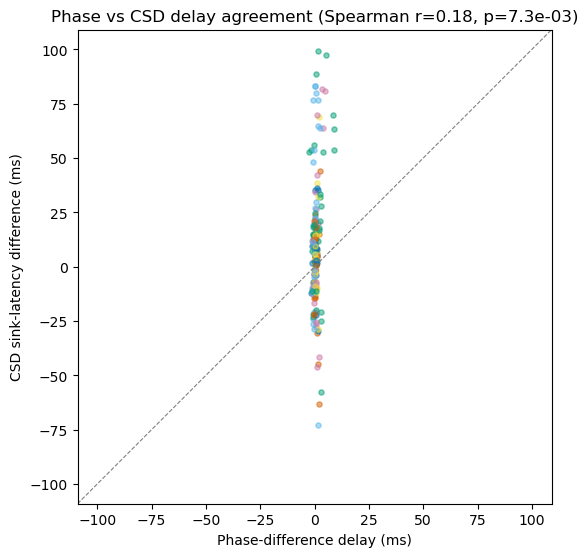

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 5.5), layout="constrained")
xs, ys = [], []
for cond in CONDITIONS:
    for band in BANDS:
        for area in ANATOMICAL_AREAS:
            rec = csd_delays[cond][band][area]
            for (ref, tgt) in [("L4", "L2/3"), ("L4", "L5/6")]:
                if ref not in rec["latency"] or tgt not in rec["latency"]:
                    continue
                phase_ms = delays[cond][band][area][(ref, tgt)]["mean_phase_ms"]
                csd_ms = rec["latency"][tgt] - rec["latency"][ref]
                xs.append(phase_ms); ys.append(csd_ms)
                ax.scatter(phase_ms, csd_ms, s=14, alpha=0.5)
xs, ys = np.array(xs), np.array(ys)
lim = np.nanmax(np.abs(np.concatenate([xs, ys]))) * 1.1
ax.plot([-lim, lim], [-lim, lim], color="gray", ls="dashed", lw=0.8)
good = ~np.isnan(xs) & ~np.isnan(ys)
if good.sum() > 2:
    r, p = stats.spearmanr(xs[good], ys[good])
    ax.set_title("Phase vs CSD delay agreement (Spearman r=%.2f, p=%.1e)" % (r, p))
ax.set_xlabel("Phase-difference delay (ms)"); ax.set_ylabel("CSD sink-latency difference (ms)")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
fig.savefig("laminar_delays/phase_vs_csd_agreement.svg", bbox_inches="tight")
plt.show(); plt.close(fig)

## Condition contrasts

Does the deviance/oddball structure change laminar propagation? For each contrast and band we test the
difference in per-trial trough delays (condition L − condition R) per area and pair with a permutation
test.

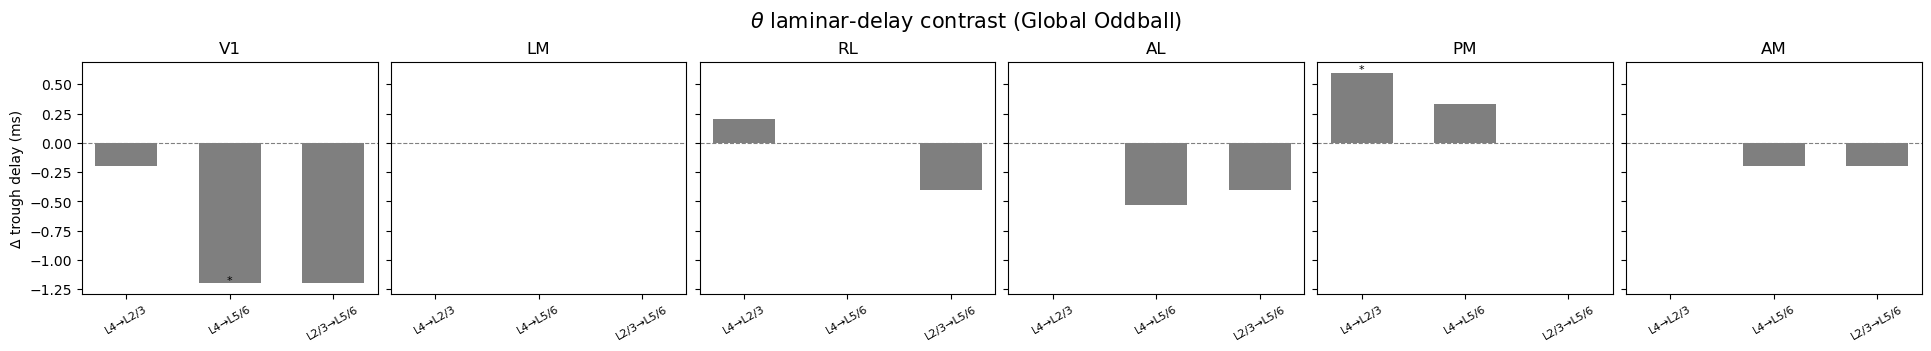

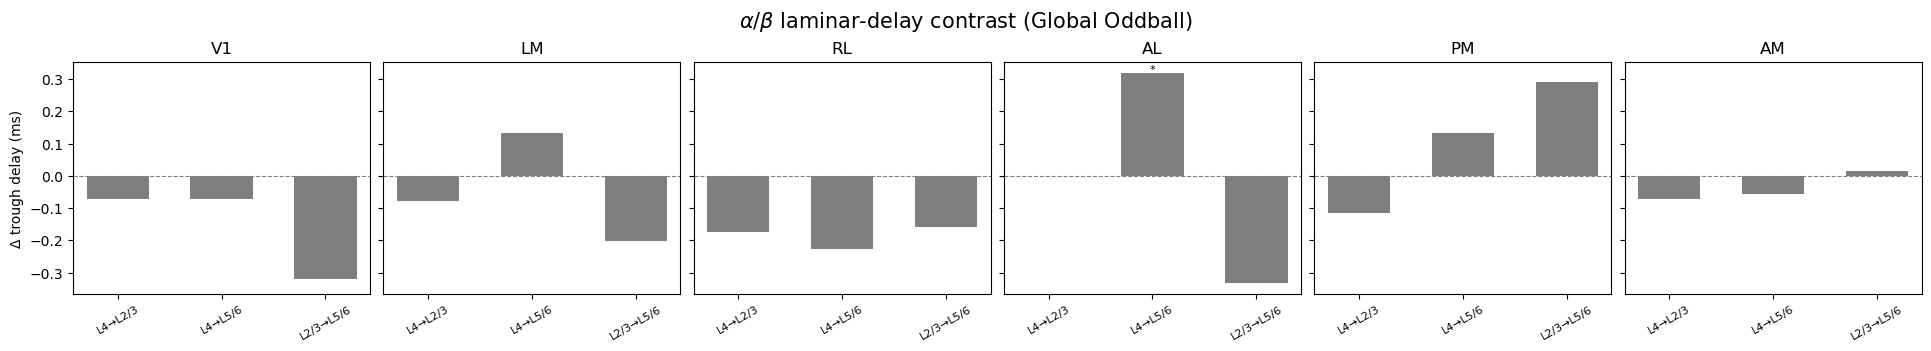

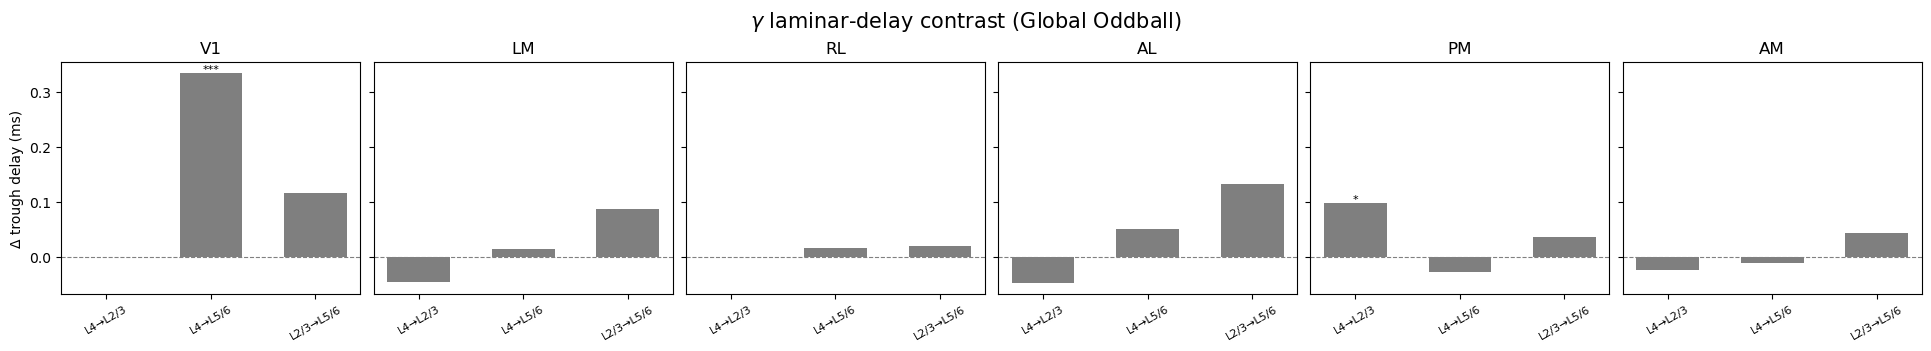

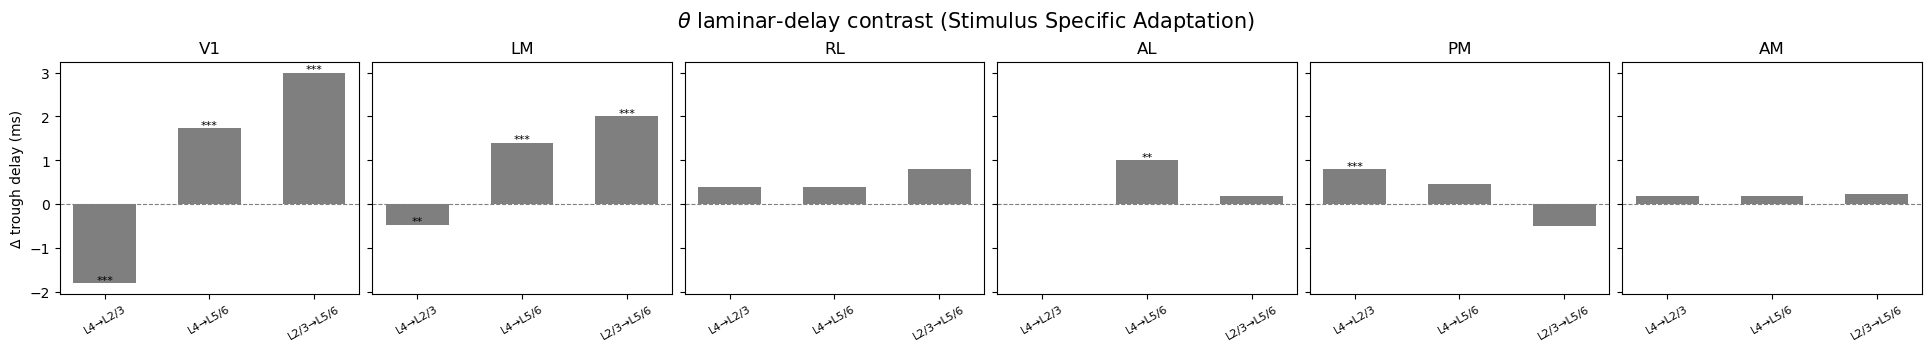

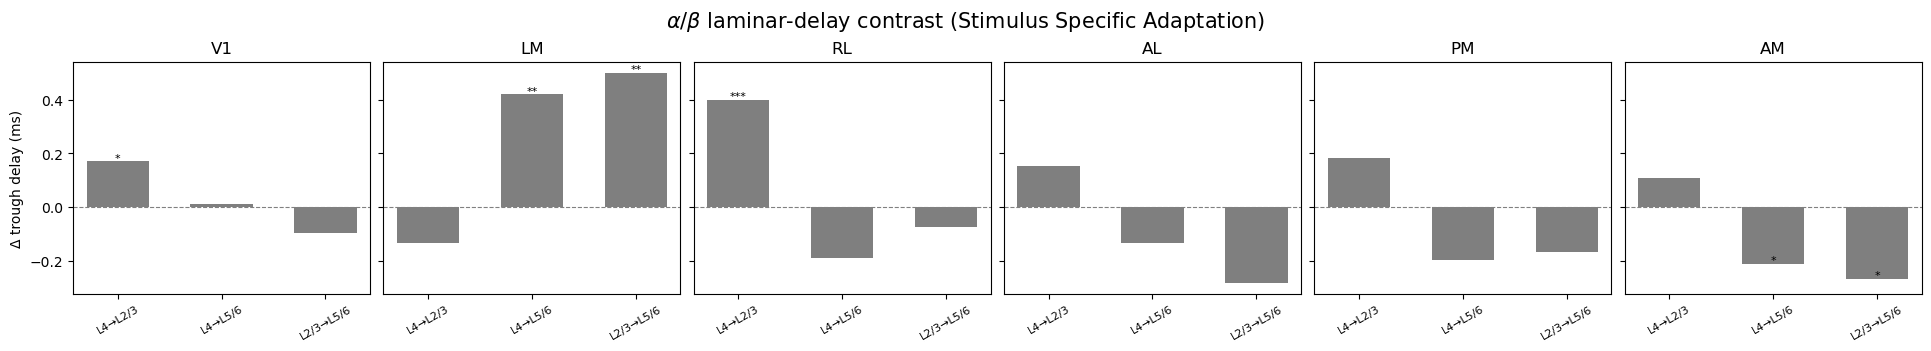

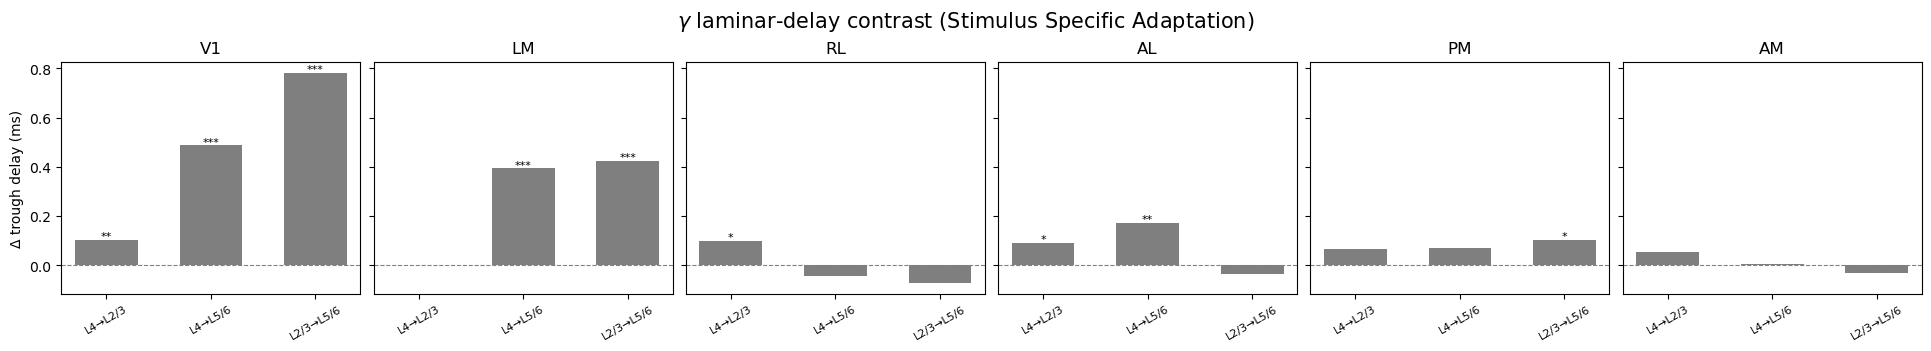

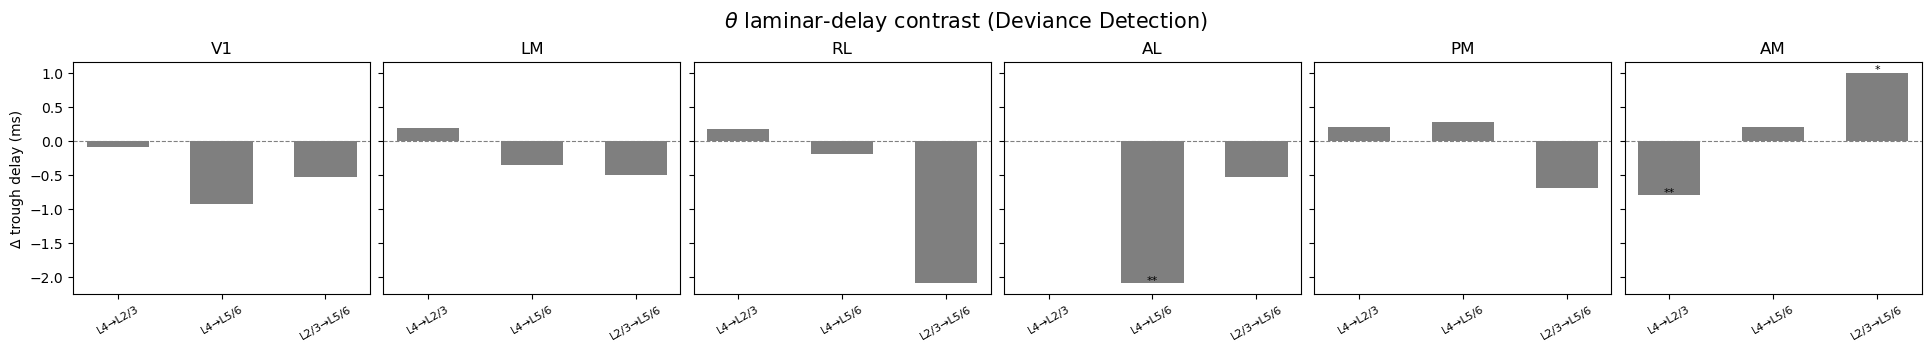

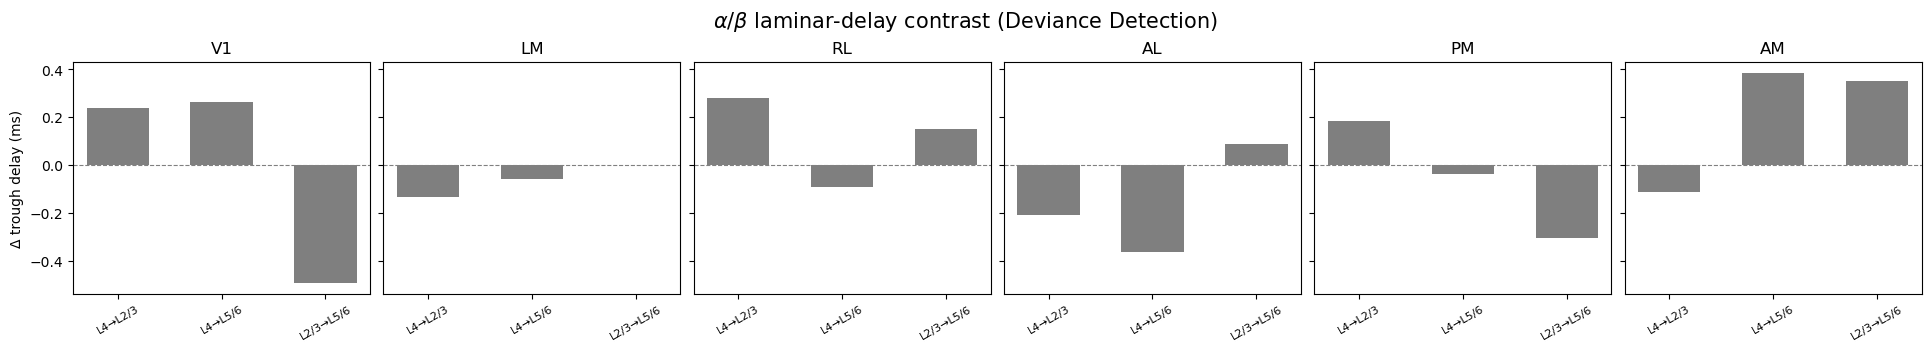

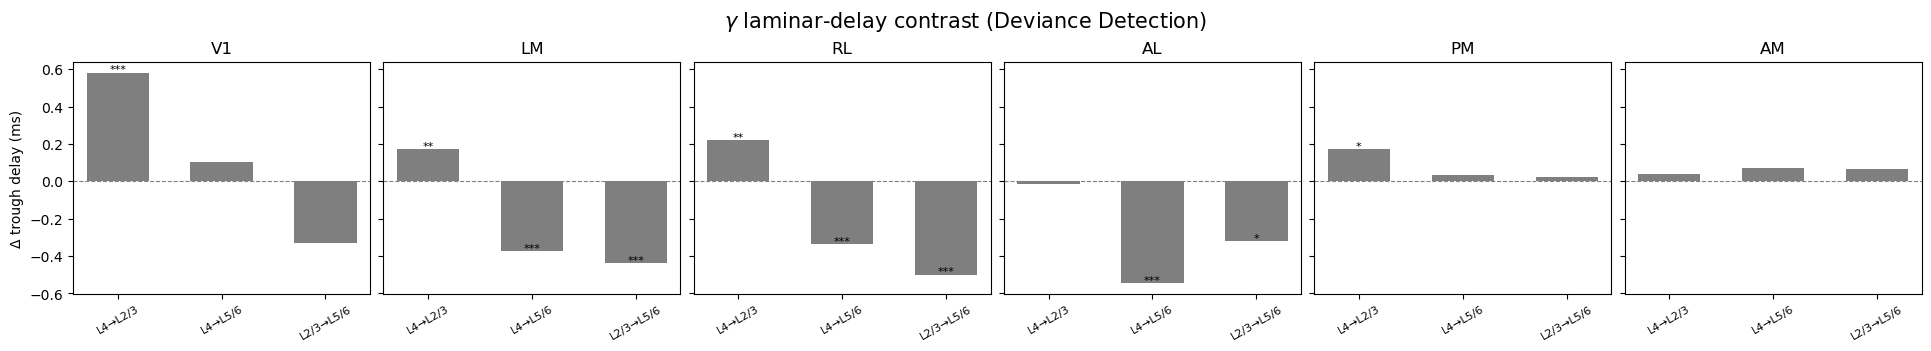

In [20]:
def plot_delay_contrast(cname, condl, condr, band):
    stem, latex = BANDS[band]
    fig, axes = plt.subplots(1, len(ANATOMICAL_AREAS), figsize=(3.2 * len(ANATOMICAL_AREAS), 3.4),
                             sharey=True, layout="constrained")
    xs = np.arange(len(LAYER_PAIRS))
    for ax, area in zip(axes, ANATOMICAL_AREAS):
        ax.axhline(0, color="gray", lw=0.8, ls="dashed")
        diffs, marks = [], []
        for pair in LAYER_PAIRS:
            a = delays[condl][band][area][pair]["trough_per_trial_ms"]
            b = delays[condr][band][area][pair]["trough_per_trial_ms"]
            obs, p = permutation_diff(a, b)
            diffs.append(obs); marks.append(stars(p))
        ax.bar(xs, diffs, 0.6, color="tab:gray")
        for x, d, s in zip(xs, diffs, marks):
            if s and s != "n.s.":
                ax.annotate(s, (x, d), ha="center", fontsize=8)
        ax.set_xticks(xs, [pair_label(p) for p in LAYER_PAIRS], rotation=30, fontsize=8)
        ax.set_title(AREA_TITLES[area])
    axes[0].set_ylabel("\u0394 trough delay (ms)")
    fig.suptitle("%s laminar-delay contrast (%s)" % (latex, CONTRAST_TITLES[cname]), fontsize=15)
    return fig

for (cname, condl, condr) in CONTRASTS:
    os.makedirs(cname + "/laminar_delays", exist_ok=True)
    for band in BANDS:
        fig = plot_delay_contrast(cname, condl, condr, band)
        fig.savefig("%s/laminar_delays/%s_delay_contrast.svg" % (cname, BANDS[band][0]),
                    bbox_inches="tight")
        plt.show(); plt.close(fig)